# Customer Lifetime Values
By: Mohamad Alif Rahmadian - AI Engineer JCAIEJKTPM-02004 - Capstone Project Module 02

[Sumber Data](https://drive.google.com/drive/folders/1GR7l3uWmcOCA2sxx1W-cEkReDxdedoeJ)

## Contents
1. Business Problem Understanding
2. Data Understanding / Exploratory Data Analysis (EDA)
   - Data Understanding
   - Exploratory Data Analysis (EDA)
4. Data Preprocessing
   - Feature Engineering
   - Train-Test Split
5. Modeling
7. Conclusion
8. Recommendation

## Business Problem Understanding

### Context
Customer Lifetime Value (CLV) merupakan estimasi total nilai (pendapatan atau laba) yang dihasilkan oleh seorang pelanggan selama seluruh masa hubungan mereka dengan suatu perusahaan. Metrik ini digunakan untuk mengukur seberapa besar kontribusi seorang pelanggan terhadap bisnis dalam jangka panjang.

Dalam konteks perusahaan asuransi kendaraan, CLV menjadi indikator penting untuk memahami nilai pelanggan, karena tidak semua pelanggan memberikan kontribusi yang sama. Beberapa pelanggan dapat bertahan dalam jangka waktu lama dan memberikan nilai tinggi, sementara yang lain hanya bertahan dalam waktu singkat.

**Rumus Customer Lifetime Value (CLV)**
$$
CLV = \text{Rata-rata Nilai Transaksi} \times \text{Frekuensi Transaksi} \times \text{Rata-rata Waktu Retensi Pelanggan}
$$

**Cara Meningkatkan CLV**
- Program Loyalitas: Memberikan insentif untuk pembelian berulang
- Personalisasi: Membuat pengalaman belanja yang disesuaikan dengan preferensi pelanggan
- Upselling/Corss-selling: Menawarkan produk tambahan atau premium (meningkatkan nilai rata-rata pesanan)
- Layanan pelanggan: Memberbaiki layanan untuk menjaga kepuasan

**Manfaat CLV**
- Mengidentifikasi pelanggan yang paling bernilai
- Membantu menentukan anggaran pemasaran (biaya akuisisi pelanggan)
- Mengoptimalkan strategi akuisisi pelanggan
- Menentukan prioritas dalam retensi pelanggan

### Problem Statement
Salah satu tantangan utama dalam industri asuransi adalah mengidentifikasi pelanggan yang memiliki potensi nilai tinggi sejak awal. Tanpa adanya estimasi CLV yang akurat, perusahaan berisiko:
- Mengalokasikan biaya pemasaran secara tidak efisien
- Menargetkan pelanggan dengan nilai rendah atau risiko tinggi
- Kehilangan peluang untuk mempertahankan pelanggan bernilai tinggi

Selain itu, karakteristik pelanggan yang beragam serta hubungan yang kompleks antara faktor-faktor seperti premi, jumlah polis, dan klaim membuat proses estimasi CLV menjadi tidak sederhana dan sulit dilakukan secara manual.

### Goals
Berdasarkan permasalahan tersebut, perusahaan membutuhkan sebuah model prediksi CLV yang dapat:
- Mengestimasi nilai CLV pelanggan berdasarkan karakteristik yang tersedia
- Membantu perusahaan dalam mengidentifikasi pelanggan dengan potensi nilai tinggi
- Mendukung pengambilan keputusan dalam strategi pemasaran, seperti targeting dan retensi pelanggan
- Mengoptimalkan alokasi sumber daya dengan fokus pada pelanggan yang memberikan kontribusi terbesar

Dengan adanya model prediksi ini, perusahaan dapat meningkatkan efisiensi bisnis serta memaksimalkan profit jangka panjang.

### Analytical Approach
Untuk menyelesaikan permasalahan tersebut, dilakukan analisis data guna memahami pola hubungan antara fitur-fitur pelanggan dengan nilai CLV.

Langkah yang dilakukan meliputi:
	1.	Melakukan eksplorasi data (EDA) untuk memahami distribusi data dan hubungan antar variabel
	2.	Mengidentifikasi faktor-faktor yang berpotensi memengaruhi CLV, seperti premi, jumlah polis, dan total klaim
	3.	Melakukan feature engineering untuk menangkap pola yang lebih kompleks, seperti rasio klaim terhadap premi
	4.	Membangun model regresi untuk memprediksi nilai CLV berdasarkan fitur-fitur yang tersedia

Model yang digunakan meliputi:
- Linear Regression sebagai baseline
- Random Forest untuk menangkap hubungan non-linear
- XGBoost sebagai model utama untuk menangkap pola kompleks secara lebih optimal

## Data Understanding / Exploratory Data Analysis (EDA)

### Data Understanding
- Setiap baris data merepresentasikan informasi terkait dengan premi seseorang

**Informasi Atribut**
| Atribut | Tipe Data | Penjelasan |
|:----------|:----------|:------------|
| Vehicle Class | String | Jenis kendaraan yang dicover oleh polis untuk setiap pelanggan |
| Coverage | String | Jenis coverage polis asuransi kendaraan yang dimiliki oleh setiap pelanggan |
| Renew Offer Type | String | Jenis renew offer type yang dimiliki oleh setiap pelanggan |
| EmploymentStatus | String | Status pekerjaan setiap pelanggan |
| Marital Status | String | Status pernikahan setiap pelanggan |
| Education | String | Pendidikan terakhir setiap pelanggan |
| Number of Policies | Float | Jumlah polis yang dimiliki oleh setiap pelanggan |
| Monthly Premium Auto | Float | Biaya premi yang dibayarkan setiap bulan
| Total Claim Amount | Float | Total biaya yang telah diclaim oleh setiap pelanggan selama mereka berlangganan |
| Income | Float | Penghasilan setiap pelanggan |
| Customer Lifetime Value | Float | Customer Lifetime Value pelanggan selama mereka menjadi anggota asuransi (USD) |

Catatan: Seluruh tipe data yang berkaitan dengan biaya/harga dicantumkan dalam US Dollar (USD/$)

#### Struktur Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data_customer_lifetime_value.csv')
df.head()

,Vehicle Class,Coverage,Renew Offer Type,EmploymentStatus,Marital Status,Education,Number of Policies,Monthly Premium Auto,Total Claim Amount,Income,Customer Lifetime Value
0,Four-Door Car,Extended,Offer1,Retired,Divorced,High School or Below,2.0,90.0,571.479602,11828.0,10083.486880
1,Four-Door Car,Basic,Offer1,Employed,Married,College,6.0,62.0,114.514440,44762.0,4943.386117
2,Two-Door Car,Basic,Offer1,Retired,Married,Master,2.0,62.0,257.248789,21514.0,11981.984810
3,Four-Door Car,Premium,Offer3,Disabled,Married,High School or Below,1.0,116.0,556.800000,17913.0,4550.856045
4,Two-Door Car,Basic,Offer3,Medical Leave,Married,High School or Below,1.0,62.0,355.820799,19030.0,2372.155492


In [3]:
# informasi mengenai dataframe
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5669 entries, 0 to 5668
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Vehicle Class            5669 non-null   str    
 1   Coverage                 5669 non-null   str    
 2   Renew Offer Type         5669 non-null   str    
 3   EmploymentStatus         5669 non-null   str    
 4   Marital Status           5669 non-null   str    
 5   Education                5669 non-null   str    
 6   Number of Policies       5669 non-null   float64
 7   Monthly Premium Auto     5669 non-null   float64
 8   Total Claim Amount       5669 non-null   float64
 9   Income                   5669 non-null   float64
 10  Customer Lifetime Value  5669 non-null   float64
dtypes: float64(5), str(6)
memory usage: 487.3 KB


In [4]:
df.describe()

,Number of Policies,Monthly Premium Auto,Total Claim Amount,Income,Customer Lifetime Value
count,5669.000000,5669.000000,5669.000000,5669.000000,5669.000000
mean,2.979361,93.026989,431.407103,37868.188569,8029.874592
std,2.393187,34.551795,287.558038,30490.490723,6916.708246
min,1.000000,61.000000,0.423310,0.000000,1898.007675
25%,1.000000,68.000000,266.932542,0.000000,3954.344534
50%,2.000000,82.000000,379.200000,34322.000000,5800.188903
75%,4.000000,109.000000,549.986128,62464.000000,9031.214859
max,9.000000,297.000000,2759.794354,99934.000000,83325.381190


#### Identifikasi Missing Value

In [5]:
df.isnull().sum()

Vehicle Class              0
Coverage                   0
Renew Offer Type           0
EmploymentStatus           0
Marital Status             0
Education                  0
Number of Policies         0
Monthly Premium Auto       0
Total Claim Amount         0
Income                     0
Customer Lifetime Value    0
dtype: int64

Berdasarkan informasi di atas, tidak ada nilai yang kosong pada dataset Customer Lifetime Values ini

##### Identifikasi data dengan nilai 0

In [6]:
(df == 0).any()

Vehicle Class              False
Coverage                   False
Renew Offer Type           False
EmploymentStatus           False
Marital Status             False
Education                  False
Number of Policies         False
Monthly Premium Auto       False
Total Claim Amount         False
Income                      True
Customer Lifetime Value    False
dtype: bool

Terdapat nilai nol (0) pada kolom Income

In [7]:
df[df["Income"] == 0]["EmploymentStatus"].unique()

<StringArray>
['Unemployed']
Length: 1, dtype: str

Terlihat bahwa seluruh data yang memiliki `Income` 0 adalah pelanggan yang `Unemployed`

In [8]:
df[df["Income"] == 0]["EmploymentStatus"].value_counts()

EmploymentStatus
Unemployed    1429
Name: count, dtype: int64

Terdapat 1332 pelanggan yang berstatus `Unemployed`

#### Identifikasi Duplicate Data

In [9]:
df.duplicated().sum()

np.int64(618)

Terlihat bahwa pada dataset ini, terdapat 618 data yang terduplikasi

In [10]:
# Melihat baris-baris yang terduplikasi
duplicated = df[df.duplicated(keep=False)]
duplicated.sort_values(list(df.columns)).head(5)

,Vehicle Class,Coverage,Renew Offer Type,EmploymentStatus,Marital Status,Education,Number of Policies,Monthly Premium Auto,Total Claim Amount,Income,Customer Lifetime Value
540,Four-Door Car,Basic,Offer1,Disabled,Divorced,Bachelor,1.0,63.0,352.394515,19864.0,2359.423599
1784,Four-Door Car,Basic,Offer1,Disabled,Divorced,Bachelor,1.0,63.0,352.394515,19864.0,2359.423599
3317,Four-Door Car,Basic,Offer1,Disabled,Divorced,Bachelor,1.0,63.0,352.394515,19864.0,2359.423599
3830,Four-Door Car,Basic,Offer1,Disabled,Divorced,Bachelor,1.0,63.0,352.394515,19864.0,2359.423599
297,Four-Door Car,Basic,Offer1,Disabled,Divorced,Master,2.0,74.0,523.888845,26057.0,8509.850887


Dataframe di atas merupakan contoh data-data yang terduplikasi pada dataset ini

### Exploratory Data Analysis

#### Visualisasi Numerical Data

##### Plot Distribusi Data Numerik

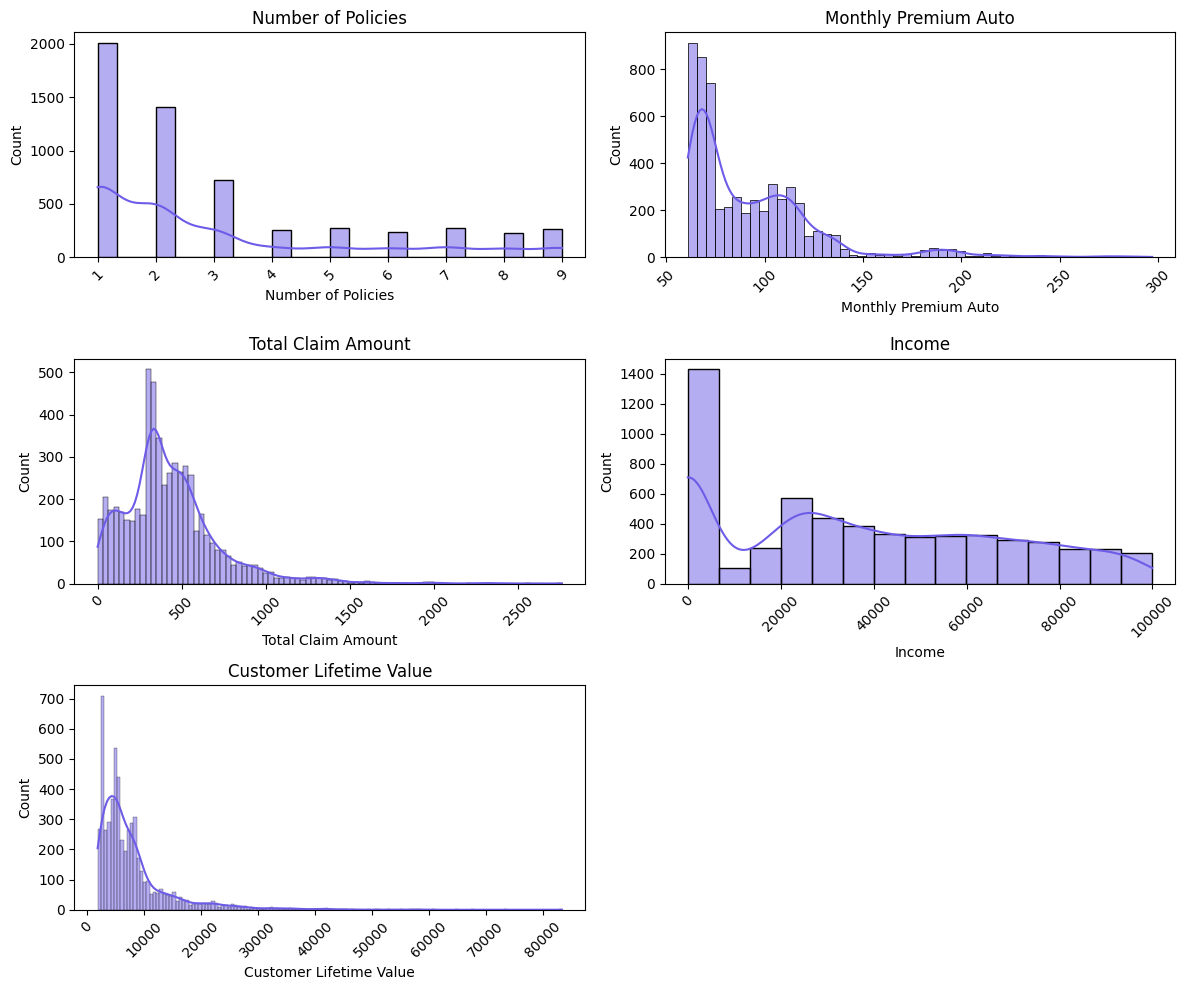

In [11]:
num_cols = df.select_dtypes(include="number").columns

plt.figure(figsize=(12,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 2, i)
    sns.histplot(
        data=df, 
        x=col, 
        color='#6C5CE7',
        kde=True
    )
    plt.xticks(rotation=45)
    plt.title(col)

plt.tight_layout()
plt.show()

Berdasarkan visualisasi distribusi variabel numerik, terlihat bahwa sebagian besar variabel memiliki distribusi yang skewed ke kanan. Hal ini menunjukkan bahwa mayoritas pelanggan berada pada nilai yang relatif rendah, sementara terdapat sejumlah kecil pelanggan dengan nilai yang sangat tinggi.

Jumlah polis menunjukkan bahwa sebagian besar pelanggan hanya memiliki 1 hingga 2 polis, sedangkan pelanggan dengan jumlah polis yang lebih banyak relatif sedikit. Monthly Premium Auto didominasi oleh nilai rendah hingga menengah, dengan beberapa pelanggan membayar premi yang jauh lebih tinggi.

Total Claim Amount juga menunjukkan pola serupa, di mana sebagian besar klaim berada pada nilai rendah, namun terdapat beberapa klaim dengan nilai yang sangat besar. Variabel Income menunjukkan adanya banyak pelanggan dengan nilai 0, yang kemungkinan merepresentasikan pelanggan yang tidak bekerja.

Customer Lifetime Value (CLV) memiliki distribusi yang sangat skewed, dengan sebagian besar pelanggan memiliki nilai CLV rendah, sementara hanya sebagian kecil pelanggan yang memiliki nilai CLV sangat tinggi.

Distribusi yang tidak normal dan adanya outlier pada beberapa variabel menjadi pertimbangan penting dalam tahap preprocessing dan modeling selanjutnya.

#### Distribusi Customer Lifetime Value

Text(0.5, 1.0, 'Customer Lifetime Value')

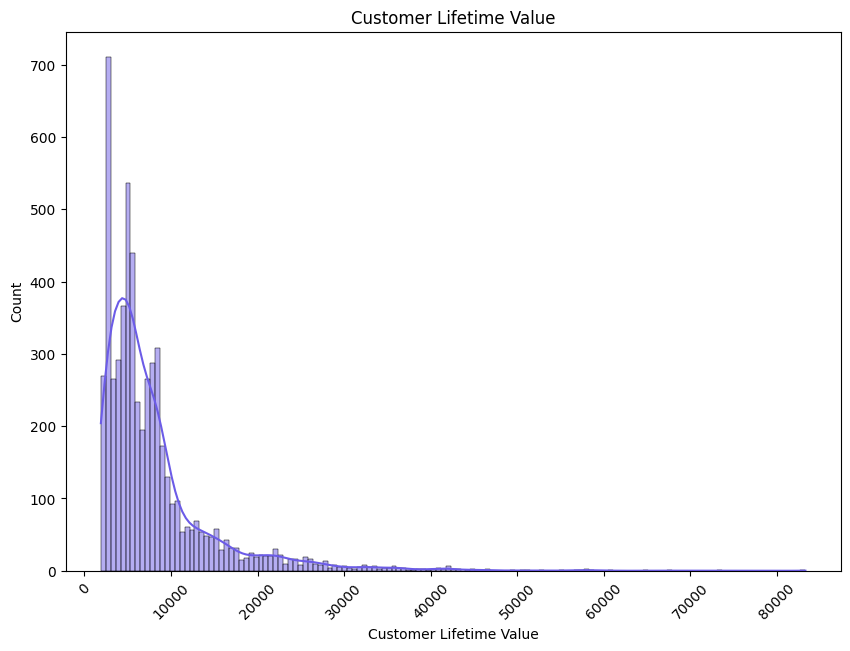

In [12]:
plt.figure(figsize=(10, 7))
sns.histplot(
    x=df["Customer Lifetime Value"], 
    color='#6C5CE7',
    kde=True
)
plt.title("Distribusi Customer Lifetime Value")
plt.xticks(rotation=45)
plt.title(col)

Distribusi Customer Lifetime Value (CLV) menunjukkan pola yang sangat right-skewed, di mana sebagian besar pelanggan memiliki nilai CLV yang relatif rendah, sementara sebagian kecil pelanggan memiliki nilai CLV yang sangat tinggi.

Hal ini mengindikasikan bahwa kontribusi nilai pelanggan tidak merata, di mana sebagian kecil pelanggan memberikan kontribusi yang signifikan terhadap total nilai bisnis. Pola ini umum ditemukan dalam data pelanggan dan mencerminkan adanya fenomena long-tail distribution.

Selain itu, nilai CLV yang tinggi tidak dianggap sebagai outlier yang harus dihapus, melainkan sebagai pelanggan bernilai tinggi yang penting untuk dipertahankan. Oleh karena itu, dalam proses modeling selanjutnya, perlu dipertimbangkan teknik transformasi seperti log transformation untuk mengatasi skewness tanpa menghilangkan informasi penting dari pelanggan dengan nilai tinggi.

##### Persebaran Data Numerik terhadap CLV

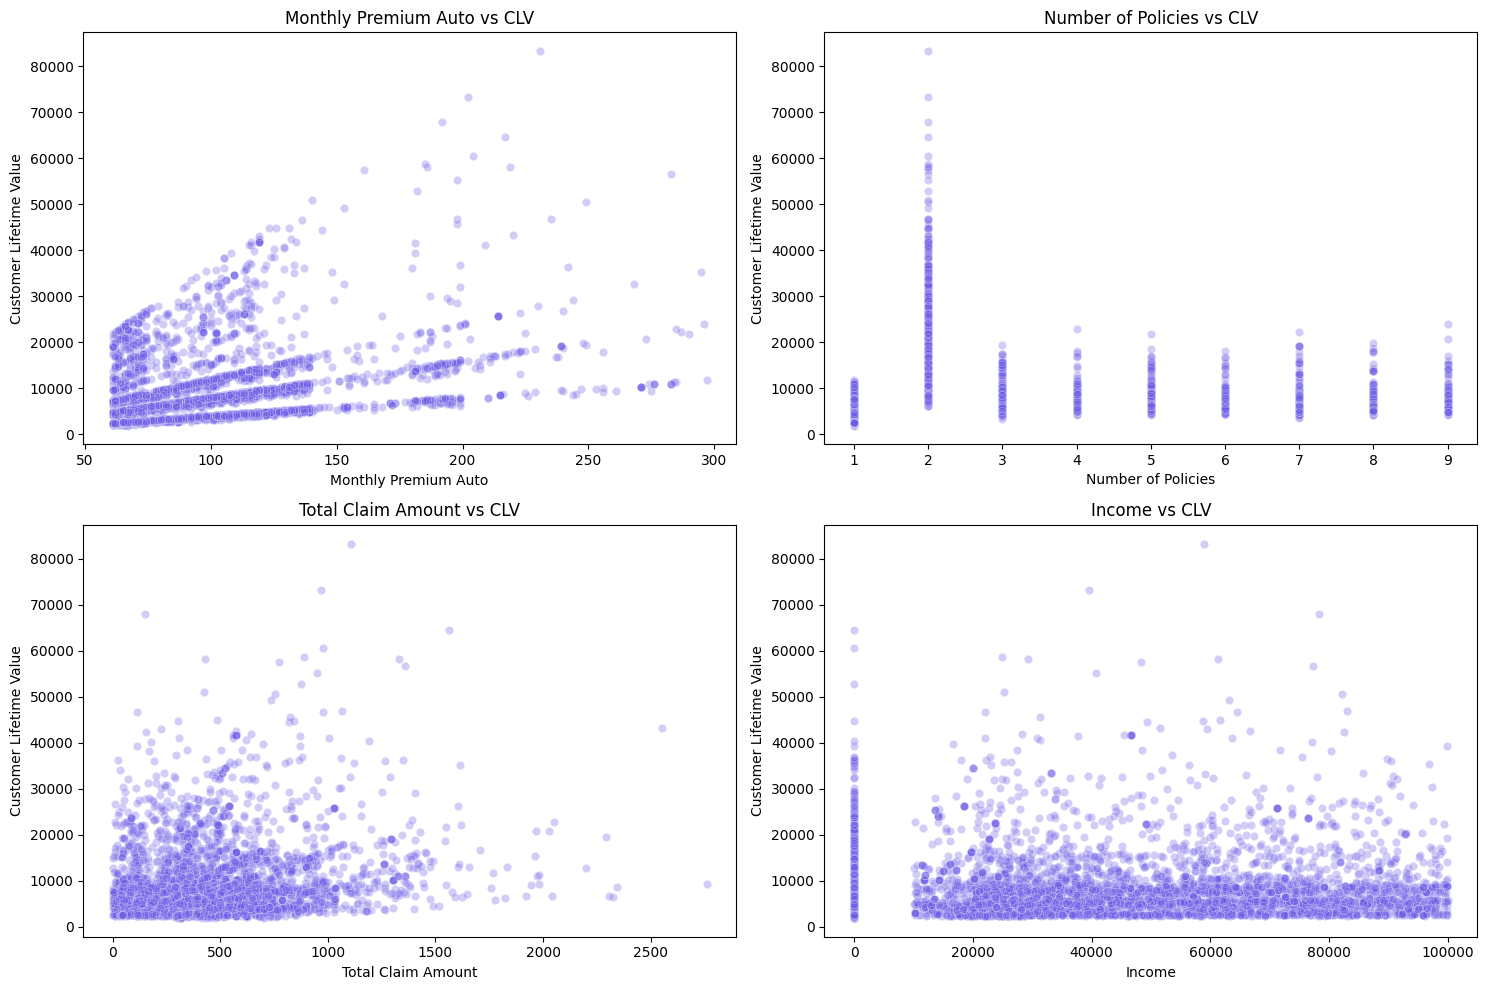

In [13]:
num_cols = [
    "Monthly Premium Auto",
    "Number of Policies",
    "Total Claim Amount",
    "Income"
]

plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.scatterplot(
        x=col,
        y="Customer Lifetime Value",
        data=df,
        alpha=0.3,
        color='#6C5CE7'
    )

    plt.title(f"{col} vs CLV")

plt.tight_layout()
plt.show()

Berdasarkan visualisasi hubungan antara variabel numerik dengan Customer Lifetime Value (CLV), terlihat bahwa tidak semua variabel memiliki pengaruh yang signifikan terhadap CLV.

Monthly Premium Auto menunjukkan hubungan positif dengan CLV, di mana pelanggan dengan premi lebih tinggi cenderung memiliki nilai CLV yang lebih tinggi. Hal ini menunjukkan bahwa CLV lebih dipengaruhi oleh besaran kontribusi premi pelanggan.

Sementara itu, Number of Policies tidak menunjukkan pola hubungan yang jelas dengan CLV, meskipun terdapat indikasi bahwa pelanggan dengan jumlah polis tertentu memiliki nilai CLV yang lebih tinggi.

Total Claim Amount juga tidak menunjukkan hubungan yang signifikan dengan CLV, yang mengindikasikan bahwa besarnya klaim tidak secara langsung menentukan nilai pelanggan. Demikian pula, Income tidak menunjukkan korelasi yang kuat dengan CLV.

Secara keseluruhan, CLV cenderung lebih dipengaruhi oleh faktor revenue dibandingkan faktor risiko maupun karakteristik demografis.

##### Total Claim Amount vs Monthly Premium Auto

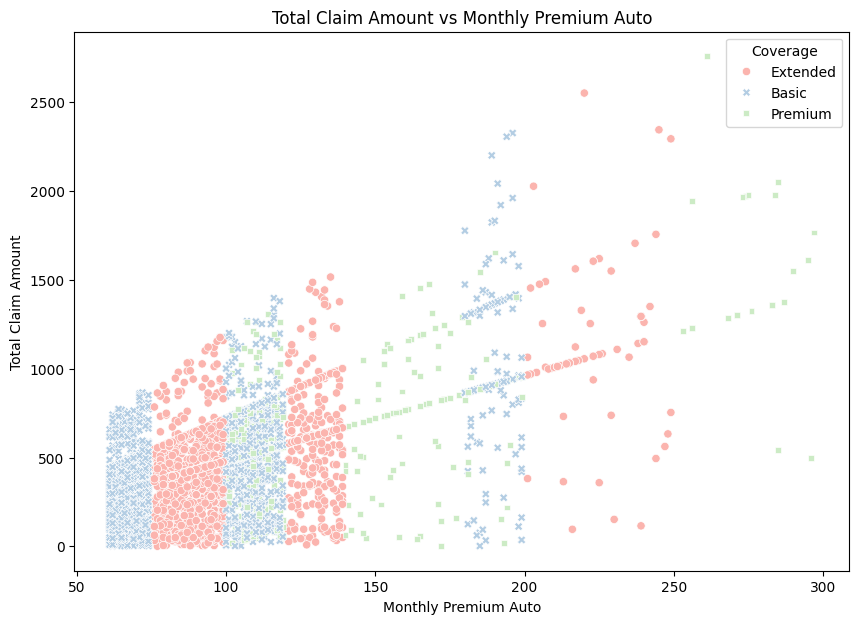

In [14]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x="Monthly Premium Auto",
    y="Total Claim Amount",
    hue="Coverage",
    palette="Pastel1",
    style="Coverage",
    data=df
)
plt.title("Total Claim Amount vs Monthly Premium Auto")
plt.show()

Visualisasi menunjukkan bahwa terdapat segmentasi yang jelas antara jenis coverage terhadap besarnya premi yang dibayarkan, di mana coverage premium memiliki premi tertinggi, diikuti oleh extended dan basic.

Selain itu, pelanggan dengan coverage yang lebih tinggi cenderung memiliki nilai klaim yang lebih besar dan lebih variatif. Namun, distribusi data menunjukkan bahwa nilai klaim yang tinggi tidak selalu menunjukkan tingkat risiko yang tinggi, terutama jika diimbangi dengan premi yang besar.

Sebaliknya, klaim yang tinggi pada premi rendah dapat mengindikasikan risiko yang lebih signifikan. Oleh karena itu, diperlukan pendekatan yang mempertimbangkan proporsi antara klaim dan premi, seperti claim ratio, untuk mengukur risiko secara lebih akurat.

#### Visualisasi Categorical Data

In [15]:
cat_cols = df.select_dtypes(include="string").columns

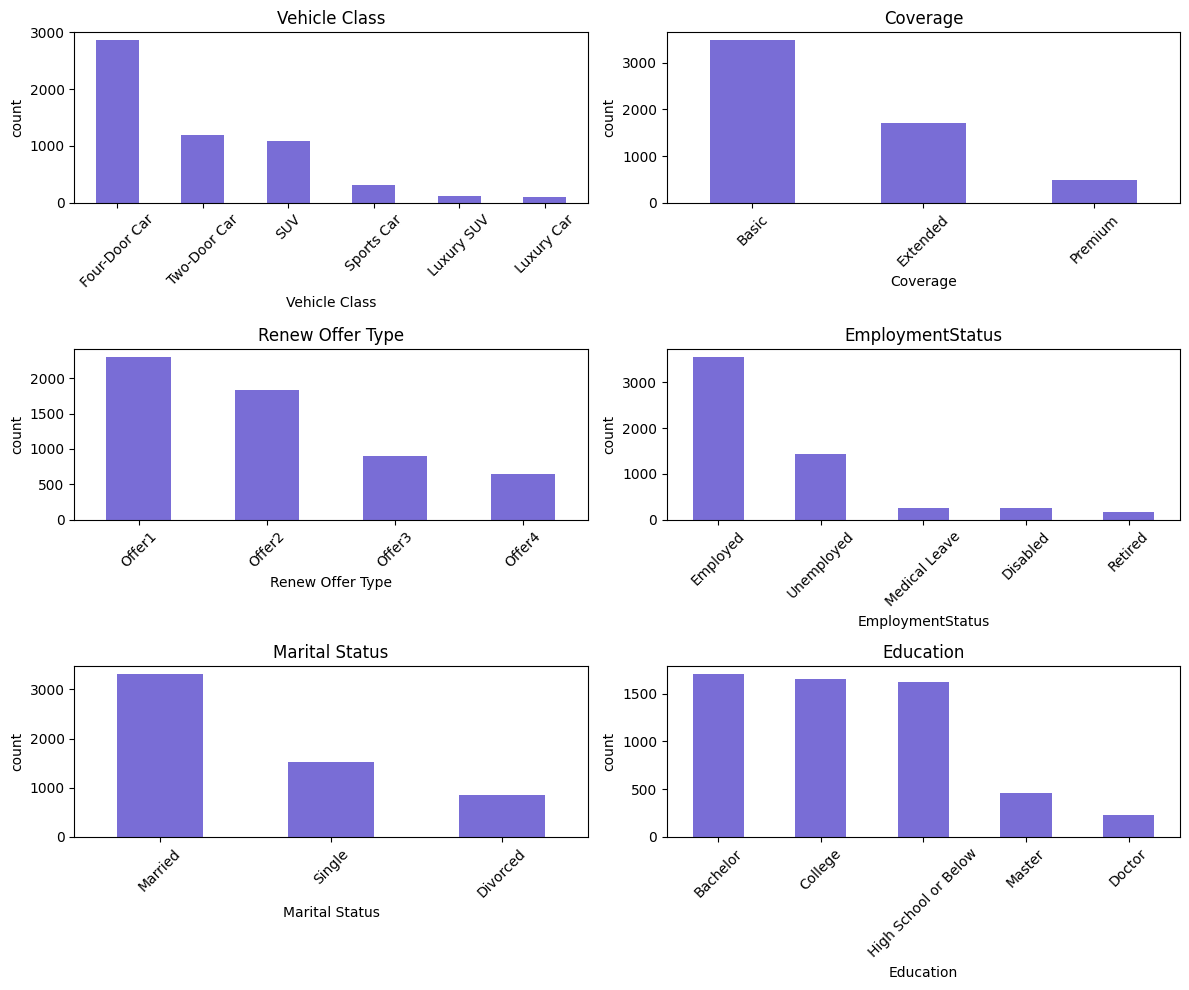

In [16]:
plt.figure(figsize=(12,10))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(3, 2, i)
    sns.countplot(data=df, 
                  x=col, 
                  color='#6C5CE7',
                  width=0.5,
                  order=df[col].value_counts(ascending=False).index
                 )
    plt.xticks(rotation=45)
    plt.title(col)

plt.tight_layout()
plt.show()

Analisis distribusi variabel kategorikal menunjukkan bahwa sebagian besar pelanggan terkonsentrasi pada kategori tertentu. Misalnya, mayoritas pelanggan menggunakan kendaraan jenis four-door car, memilih coverage basic, dan berstatus employed serta married.

Selain itu, beberapa kategori seperti kendaraan mewah (luxury), coverage premium, dan status pekerjaan tertentu memiliki jumlah yang relatif sedikit, menunjukkan adanya ketidakseimbangan distribusi data.

Distribusi ini mengindikasikan adanya segmentasi pelanggan yang cukup jelas, di mana sebagian besar pelanggan berada pada kelompok dengan karakteristik umum, sementara kelompok dengan karakteristik khusus (seperti premium coverage atau kendaraan mewah) hanya mencakup sebagian kecil populasi. Hal ini perlu diperhatikan dalam proses modeling karena dapat memengaruhi performa model, terutama dalam menangkap pola dari kategori minoritas.

Distribusi kategori yang tidak seimbang juga dapat menjadi pertimbangan dalam proses encoding atau modeling, terutama jika kategori minoritas memiliki pengaruh signifikan terhadap target variabel.

##### Categorical Data vs CLV

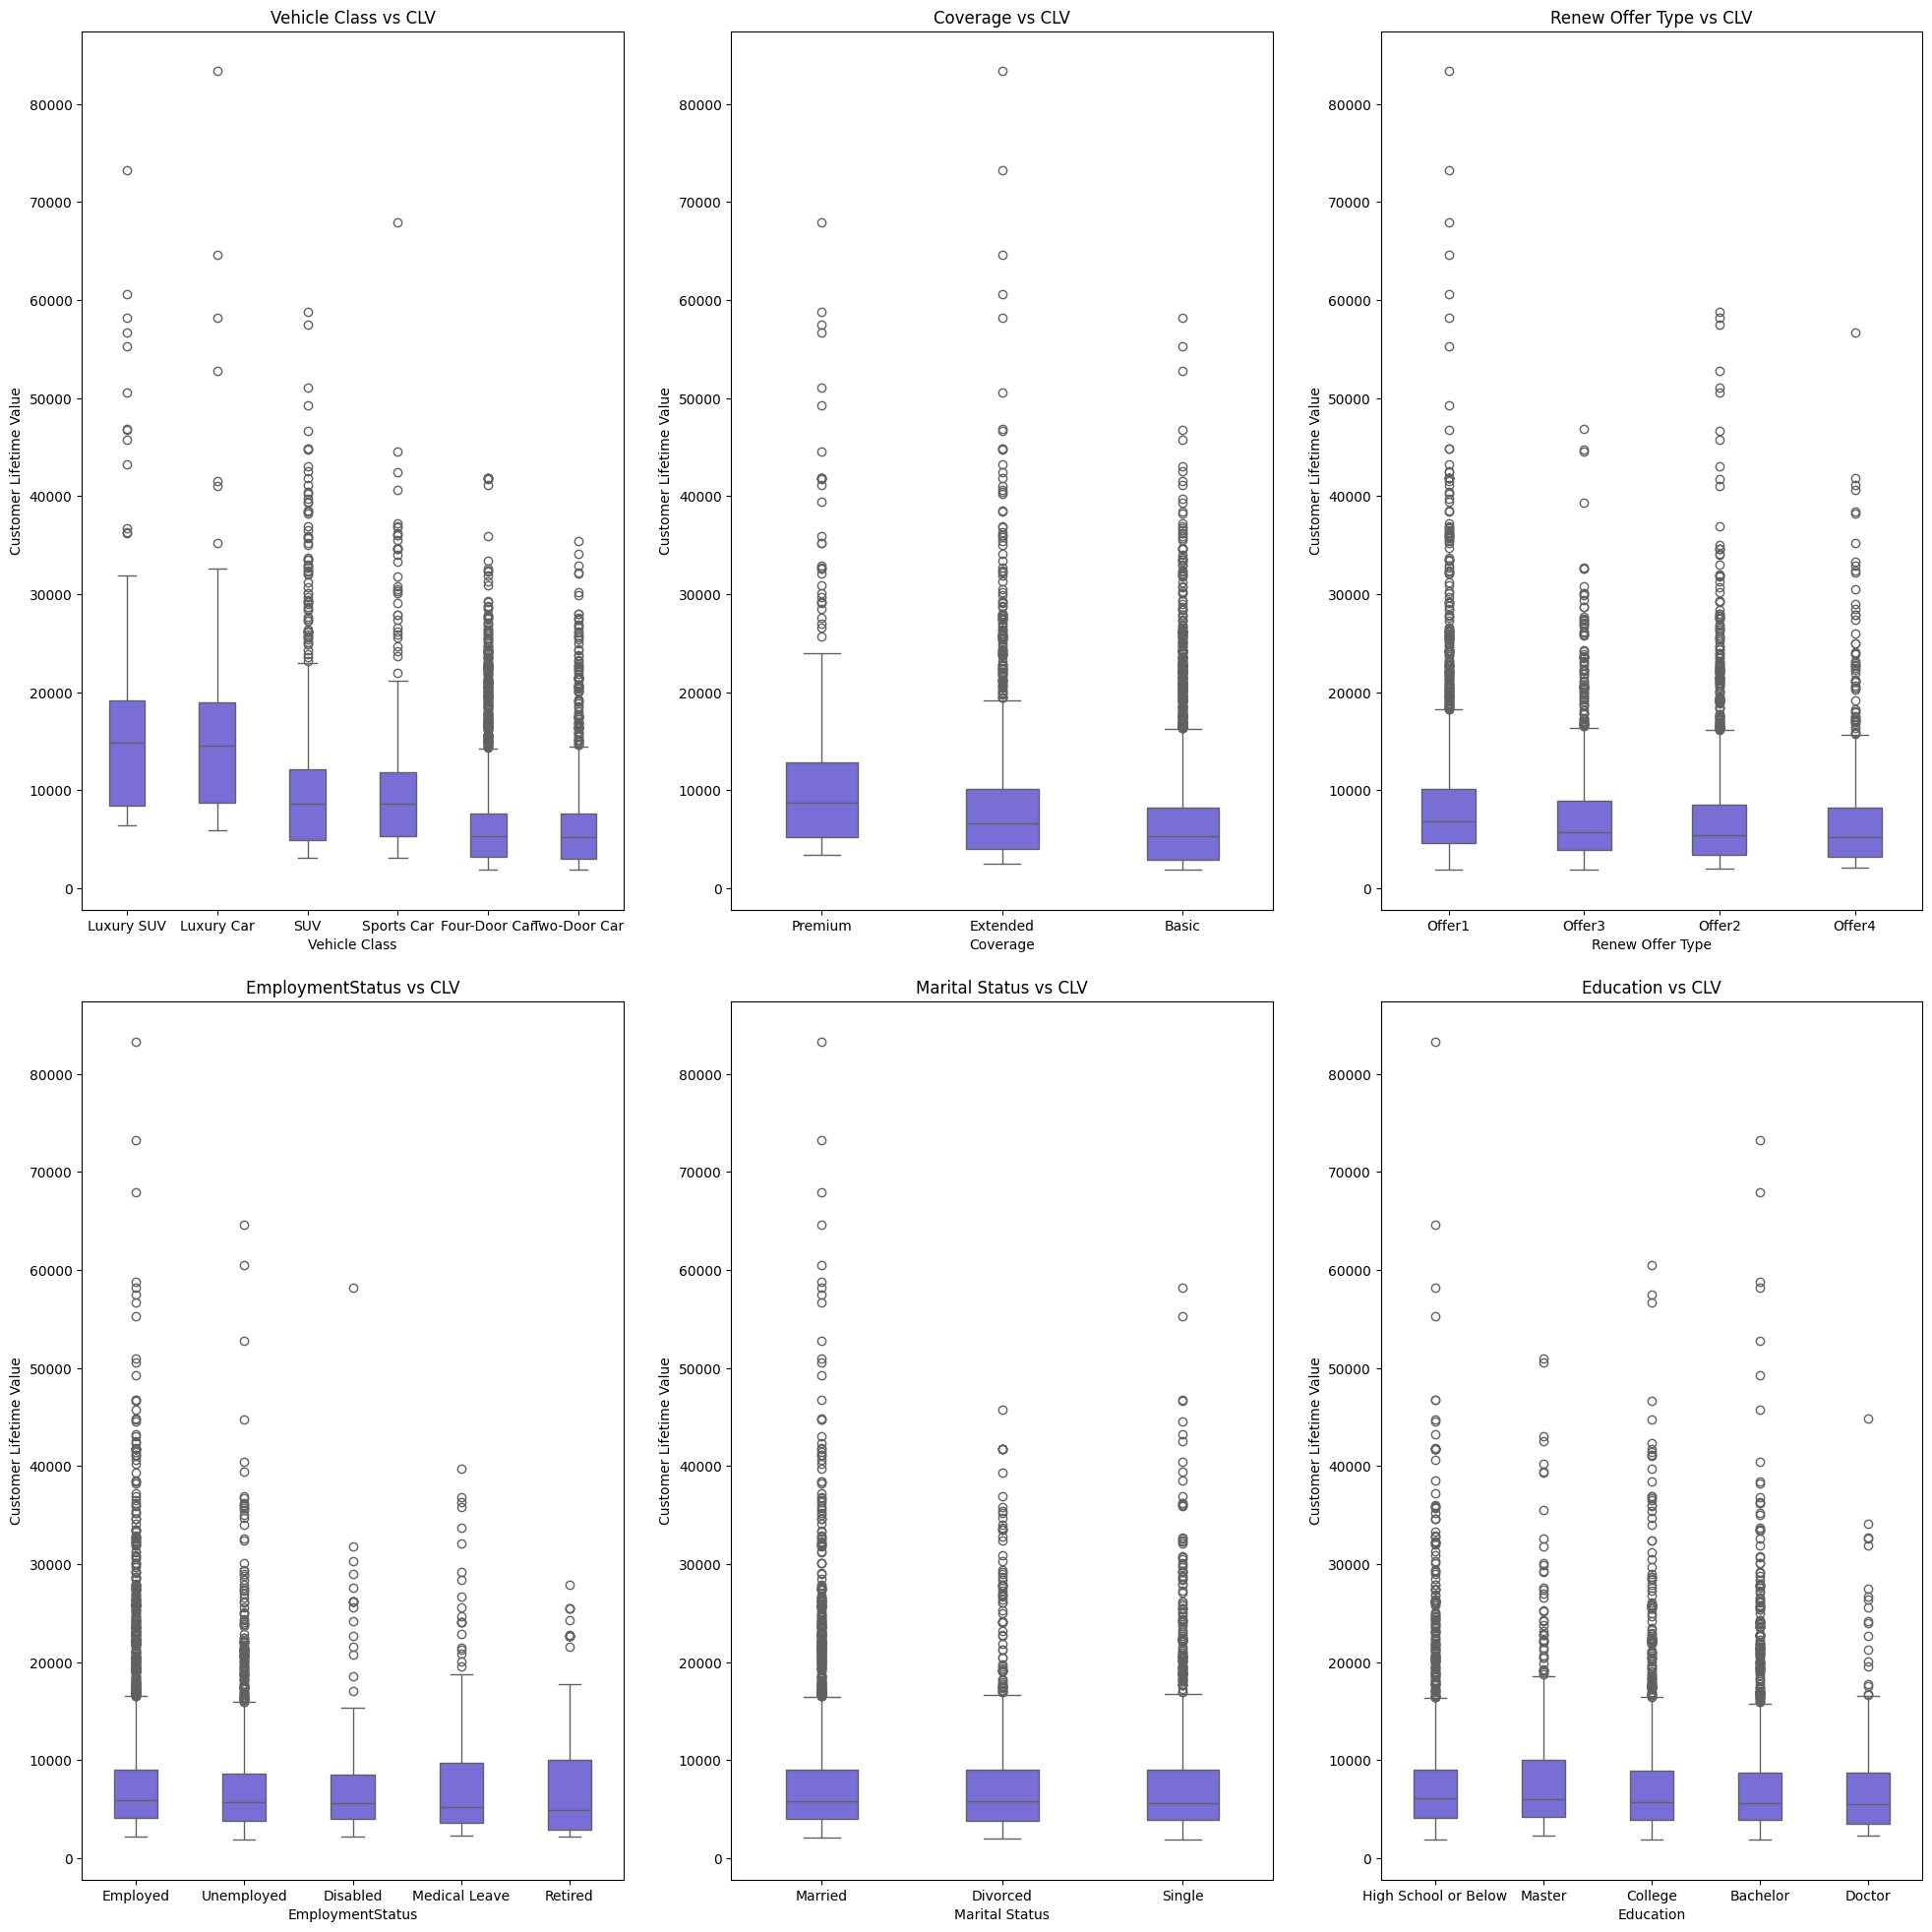

In [17]:
plt.figure(figsize=(20, 20))

for i, col in enumerate(cat_cols, 1):
    order = df.groupby(col)['Customer Lifetime Value'].median().sort_values(ascending=False).index
    
    plt.subplot(2, 3, i)
    sns.boxplot(x=col, 
                y="Customer Lifetime Value", 
                data=df, 
                color='#6C5CE7',
                width=0.4,
                order=order
               )
    plt.title(f"{col} vs CLV")

plt.tight_layout(pad=2.0)
plt.show()

Analisis hubungan antara variabel kategorikal dan Customer Lifetime Value (CLV) menunjukkan bahwa tidak semua variabel memiliki pengaruh yang sama terhadap nilai CLV.

Variabel seperti Vehicle Class dan Coverage menunjukkan pola yang cukup jelas, di mana pelanggan dengan kendaraan yang lebih mewah dan coverage yang lebih tinggi cenderung memiliki nilai CLV yang lebih besar. Hal ini mengindikasikan bahwa faktor terkait produk dan premi memiliki peran penting dalam menentukan nilai pelanggan.

Sebaliknya, variabel demografis seperti Employment Status, Marital Status, dan Education tidak menunjukkan perbedaan yang signifikan terhadap CLV, dengan distribusi yang cenderung saling tumpang tindih antar kategori.

Selain itu, terdapat banyak overlap pada distribusi CLV di hampir semua kategori, yang menunjukkan bahwa tidak ada satu variabel kategorikal yang secara tunggal dapat menjelaskan variasi CLV. Oleh karena itu, diperlukan kombinasi beberapa fitur, termasuk hasil feature engineering, untuk membangun model prediksi yang lebih akurat.

CLV tidak ditentukan oleh satu faktor, tetapi merupakan hasil kombinasi berbagai faktor termasuk premi, klaim, dan karakteristik pelanggan.

##### Perbandingan Harga Premi Terhadap Jenis Mobil

In [18]:
# median

df.groupby('Vehicle Class')['Monthly Premium Auto'].median()

Vehicle Class
Four-Door Car     72.0
Luxury Car       193.0
Luxury SUV       201.0
SUV              115.0
Sports Car       116.0
Two-Door Car      71.0
Name: Monthly Premium Auto, dtype: float64

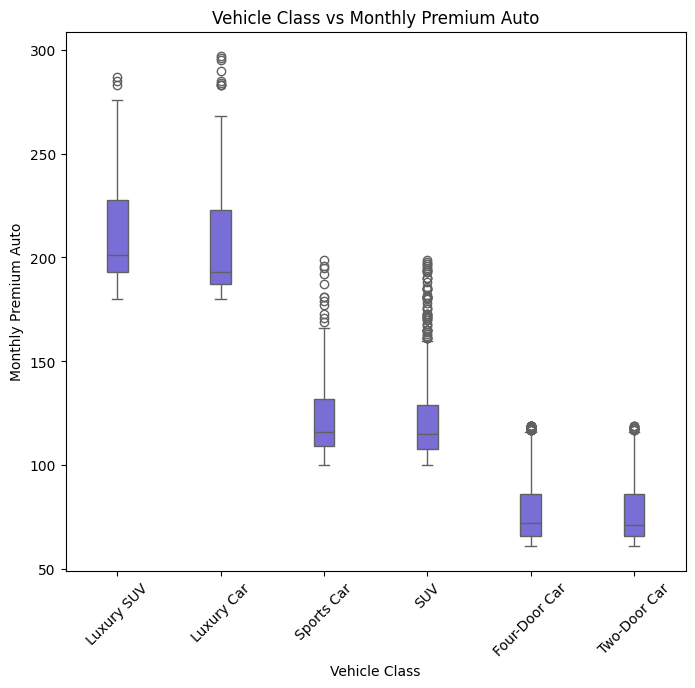

In [19]:
order = df.groupby('Vehicle Class')['Monthly Premium Auto'].median().sort_values(ascending=False).index

plt.figure(figsize=(8, 7))
sns.boxplot(
    x="Vehicle Class",
    y="Monthly Premium Auto",
    color='#6C5CE7',
    order=order,
    data=df,
    width=0.2
)

plt.xticks(rotation=45)
plt.title("Vehicle Class vs Monthly Premium Auto")
plt.show()

Terlihat bahwa jenis kendaraan memiliki pengaruh yang signifikan terhadap besaran premi asuransi bulanan. Kendaraan dengan kelas lebih tinggi seperti Luxury Car dan Luxury SUV memiliki premi yang jauh lebih besar dibandingkan kategori lainnya.

Distribusi premi juga menunjukkan adanya segmentasi yang jelas menjadi tiga kelompok utama, yaitu kendaraan premium (Luxury), menengah (SUV dan Sports Car), dan ekonomi (Four-Door dan Two-Door Car).

Selain itu, terdapat variasi premi yang cukup besar dalam setiap kategori, yang mengindikasikan bahwa faktor lain seperti coverage dan profil risiko juga turut memengaruhi besaran premi.

##### Perbandingan Harga Premi Terhadap Coverage

In [20]:
df.groupby('Coverage')['Monthly Premium Auto'].median()

Coverage
Basic        70.0
Extended     92.0
Premium     114.0
Name: Monthly Premium Auto, dtype: float64

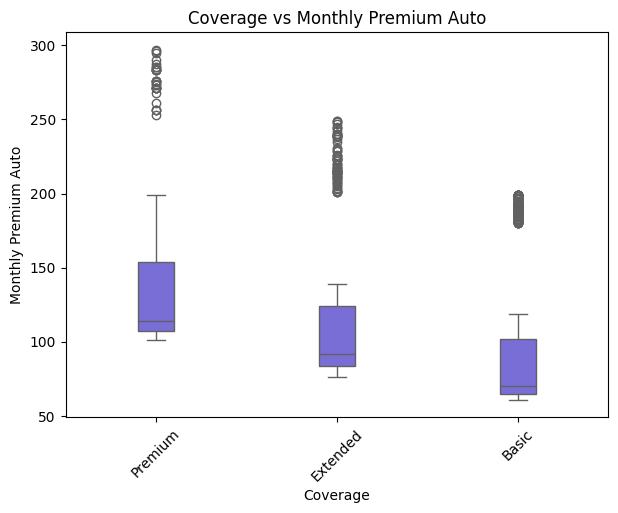

In [21]:
order = df.groupby('Coverage')['Monthly Premium Auto'].median().sort_values(ascending=False).index

plt.figure(figsize=(7, 5))
sns.boxplot(
    x="Coverage",
    y="Monthly Premium Auto",
    color='#6C5CE7',
    order=order,
    data=df,
    width=0.2
)

plt.xticks(rotation=45)
plt.title("Coverage vs Monthly Premium Auto")
plt.show()

Berdasarkan visualisasi boxplot, terlihat bahwa jenis coverage memiliki pengaruh yang signifikan terhadap besaran Monthly Premium Auto. Coverage Premium memiliki median premi tertinggi, diikuti oleh Extended, dan Basic sebagai yang terendah.

Selain itu, variasi premi juga cenderung meningkat seiring dengan meningkatnya level coverage. Coverage Premium menunjukkan distribusi yang lebih lebar serta banyak outlier dengan nilai premi yang sangat tinggi, yang mengindikasikan adanya pelanggan dengan risiko tinggi atau tambahan perlindungan.

Sebaliknya, Coverage Basic memiliki premi yang lebih rendah dan distribusi yang relatif lebih stabil. Hal ini menunjukkan adanya segmentasi harga yang jelas berdasarkan tingkat coverage yang dipilih oleh pelanggan.

##### Perbandingan Total Claim Amount terhadap kolom kategorikal lainnya

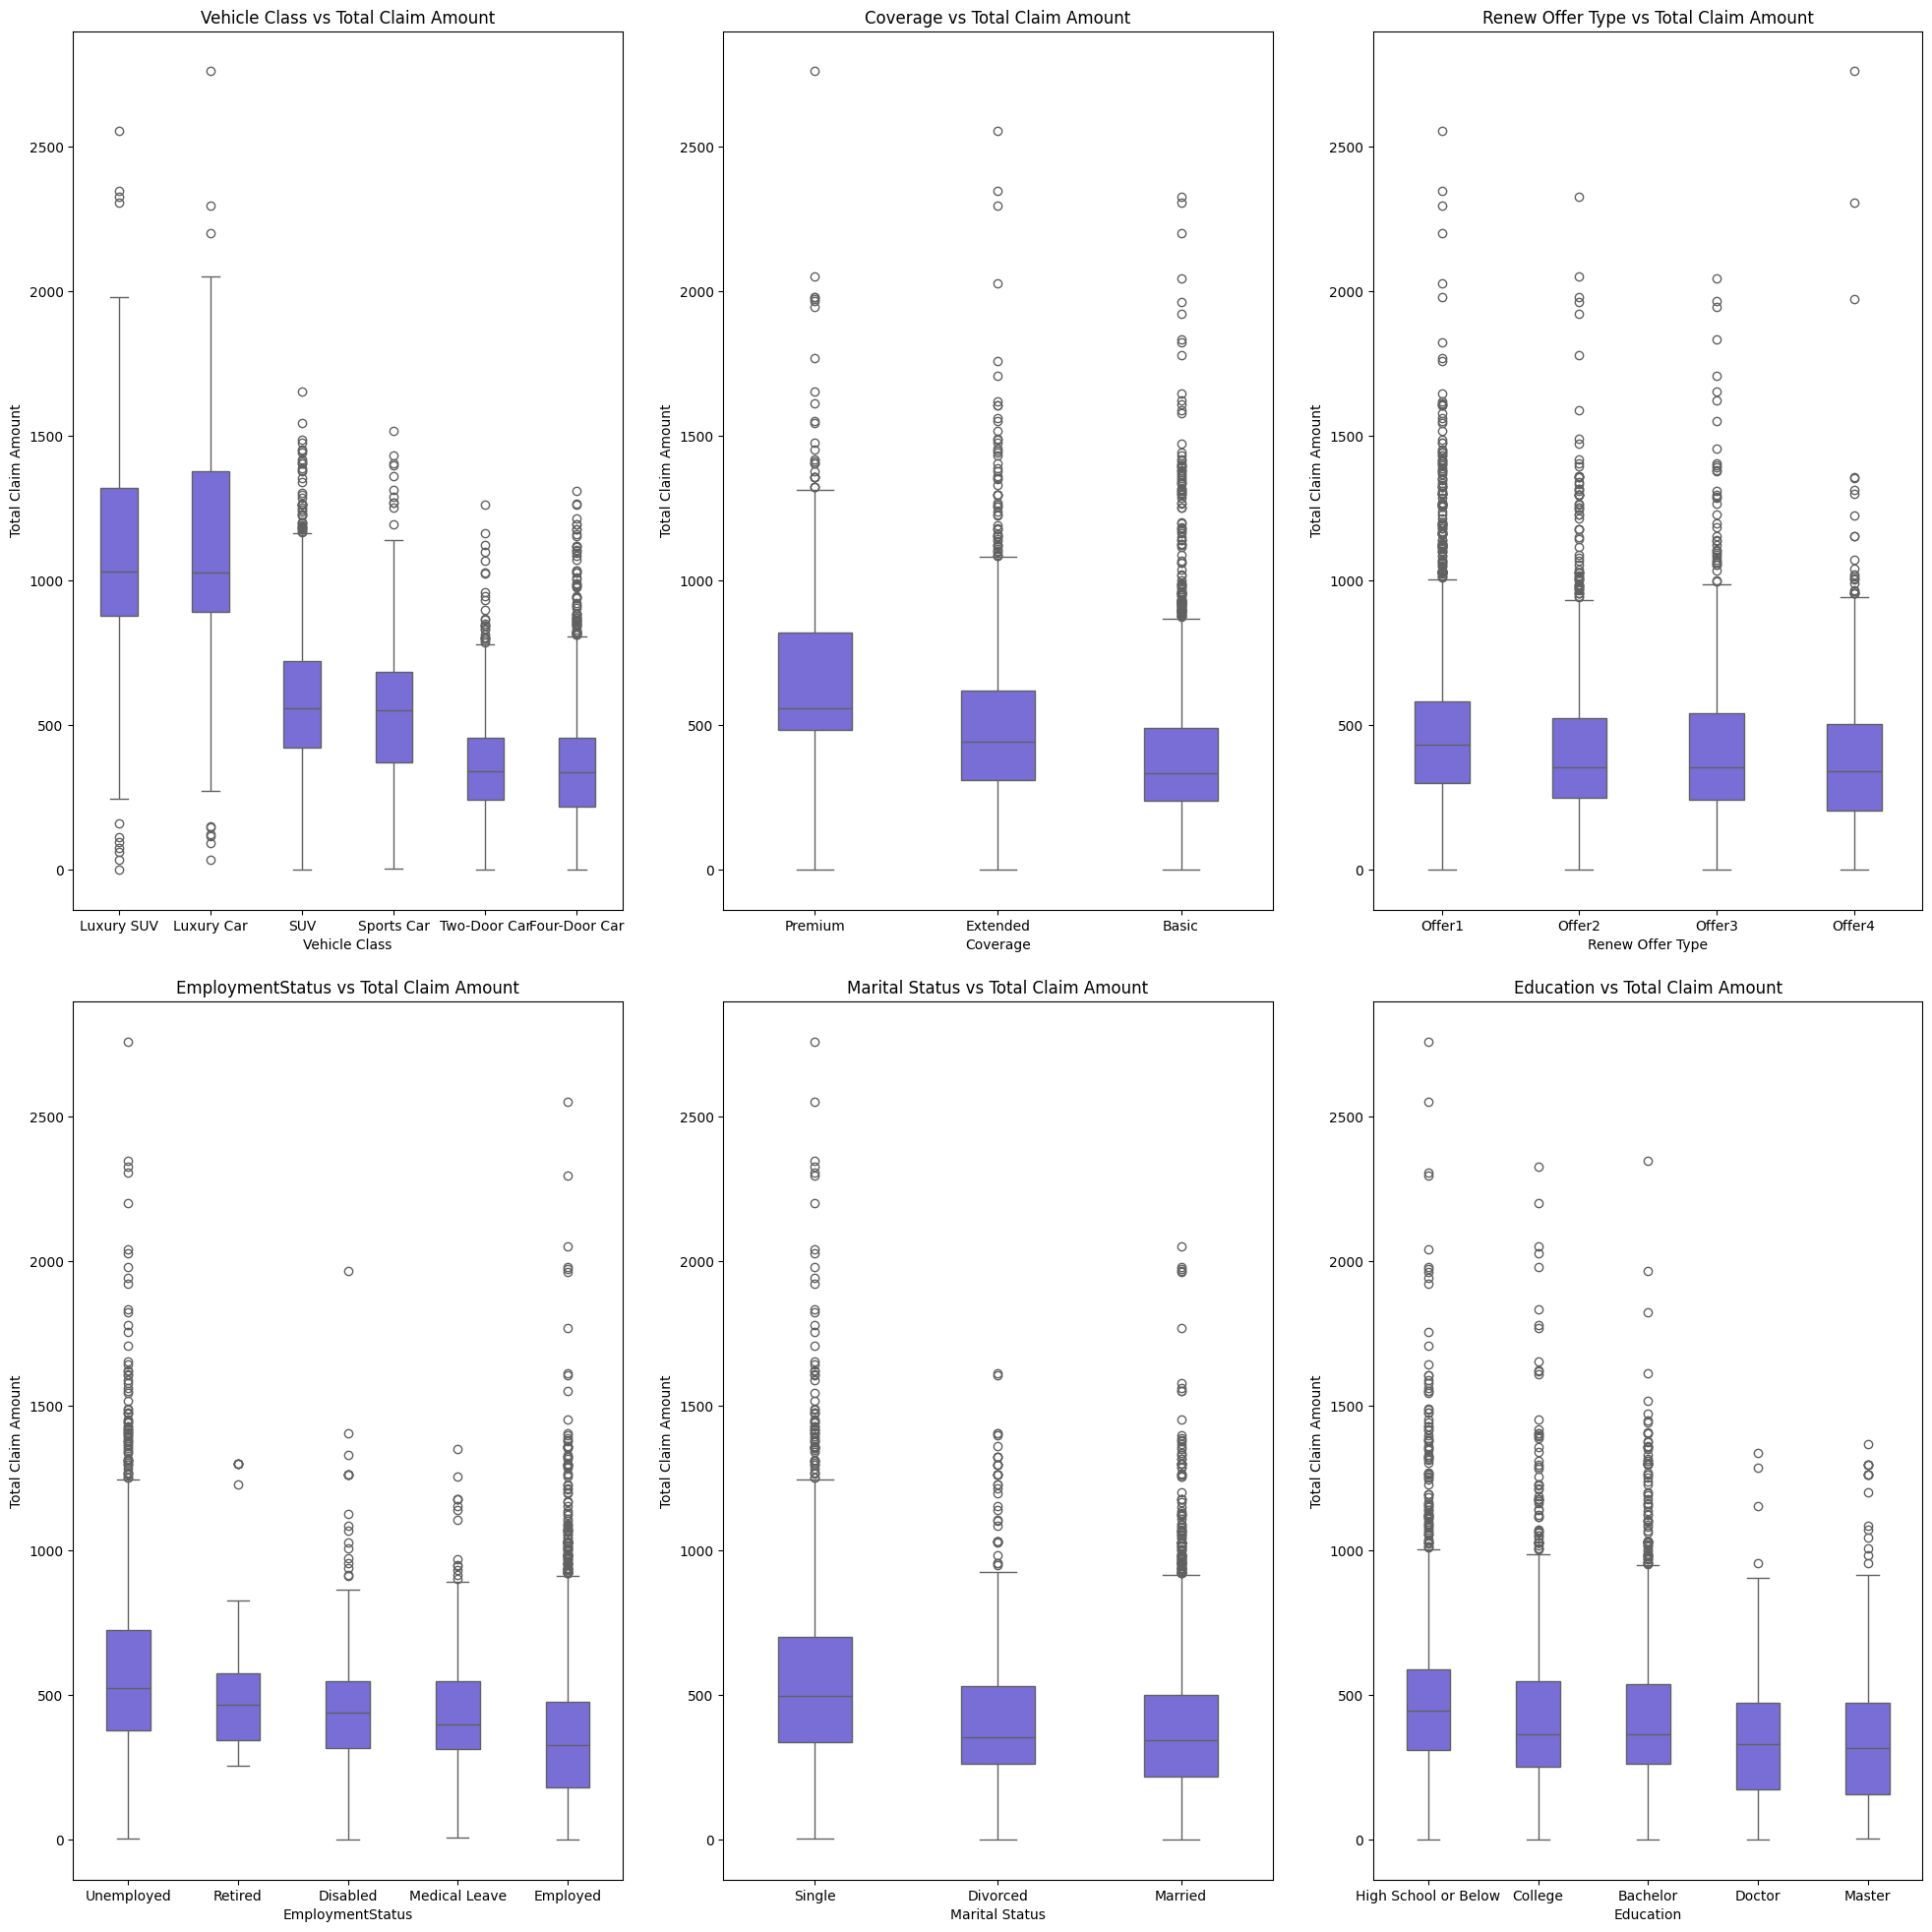

In [22]:
plt.figure(figsize=(20, 20))

for i, col in enumerate(cat_cols, 1):
    order = df.groupby(col)['Total Claim Amount'].median().sort_values(ascending=False).index
    
    plt.subplot(2, 3, i)
    sns.boxplot(x=col, 
                y="Total Claim Amount", 
                data=df, 
                color='#6C5CE7',
                width=0.4,
                order=order
               )
    plt.title(f"{col} vs Total Claim Amount")

plt.tight_layout(pad=2.0)
plt.show()

Berdasarkan visualisasi, terlihat bahwa Total Claim Amount dipengaruhi oleh beberapa faktor utama, terutama jenis kendaraan dan coverage.

Kendaraan dengan kelas lebih tinggi seperti Luxury Car dan Luxury SUV cenderung memiliki total claim yang lebih besar dibandingkan kendaraan lainnya. Hal ini kemungkinan disebabkan oleh biaya perbaikan yang lebih tinggi atau nilai kendaraan yang lebih mahal.

Selain itu, pelanggan dengan coverage Premium memiliki total claim yang lebih tinggi dibandingkan Extended dan Basic. Hal ini menunjukkan bahwa semakin luas perlindungan yang dimiliki, semakin besar klaim yang dapat diajukan.

Sementara itu, faktor demografis seperti Employment Status menunjukkan pengaruh yang lebih kecil, dengan pelanggan yang tidak bekerja cenderung memiliki claim yang sedikit lebih tinggi. Namun, variabel seperti Marital Status dan Education tidak menunjukkan perbedaan yang signifikan, sehingga kemungkinan bukan faktor utama dalam menentukan besaran klaim.

Secara keseluruhan, faktor yang memengaruhi total claim amount cenderung sejalan dengan faktor yang memengaruhi premium, yang mengindikasikan bahwa penentuan harga premi telah mempertimbangkan profil risiko pelanggan.

#### Correlation Matrix

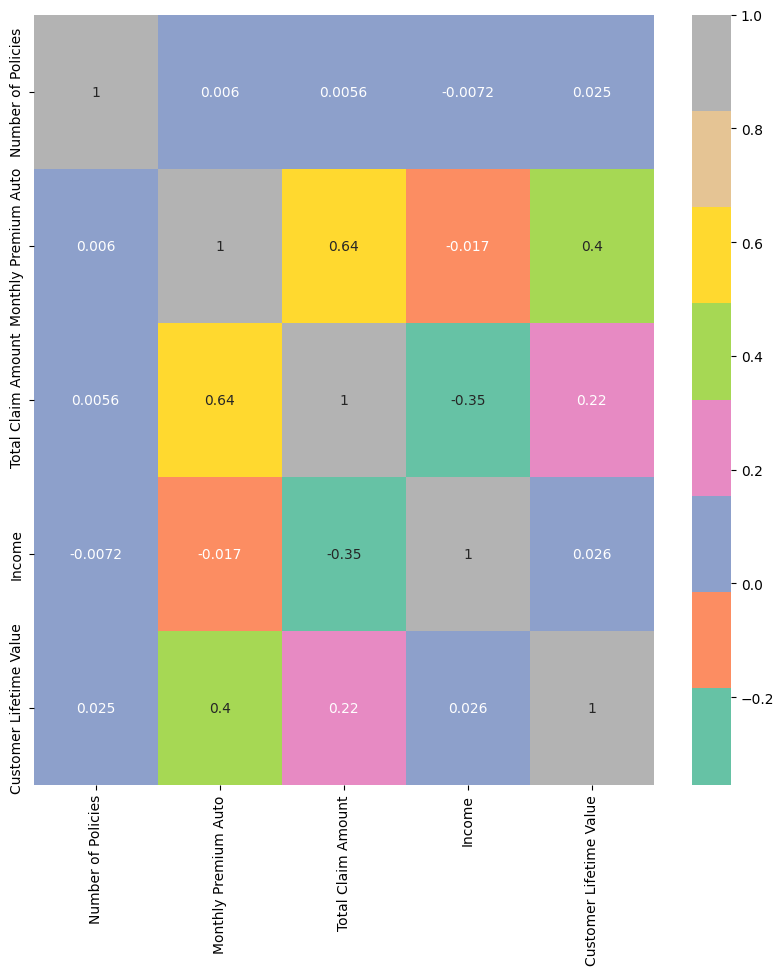

In [23]:
plt.figure(figsize=(10,10))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap="Set2")
plt.show()

Berdasarkan analisis korelasi, tidak ditemukan hubungan yang sangat kuat antara variabel numerik dengan Customer Lifetime Value (CLV). Namun, Monthly Premium Auto menunjukkan korelasi positif moderat terhadap CLV, yang mengindikasikan bahwa pelanggan dengan premi lebih tinggi cenderung memiliki nilai CLV yang lebih besar.

Total Claim Amount juga memiliki hubungan positif terhadap CLV, meskipun tidak terlalu kuat. Sementara itu, variabel seperti Income dan Number of Policies hampir tidak menunjukkan hubungan linear yang signifikan dengan CLV.

Selain itu, terdapat korelasi yang cukup kuat antara Monthly Premium Auto dan Total Claim Amount, yang menunjukkan bahwa pelanggan dengan premi tinggi cenderung memiliki nilai klaim yang lebih besar. Hal ini mengindikasikan bahwa kedua variabel tersebut saling berkaitan dan perlu dianalisis secara relatif.

Oleh karena itu, diperlukan feature engineering seperti claim ratio untuk menangkap hubungan antara klaim dan premi secara lebih representatif dalam mengukur risiko pelanggan.

#### Kesimpulan

Berdasarkan hasil Exploratory Data Analysis (EDA), diperoleh pemahaman yang komprehensif mengenai karakteristik data serta hubungan antar variabel.

Distribusi variabel numerik menunjukkan pola right-skewed dengan adanya outlier, terutama pada Customer Lifetime Value (CLV) dan Total Claim Amount. Outlier ini tidak dianggap sebagai noise, melainkan merepresentasikan pelanggan bernilai tinggi yang penting secara bisnis.

Analisis hubungan antara variabel numerik dan CLV menunjukkan bahwa Monthly Premium Auto memiliki pengaruh paling signifikan dengan korelasi positif moderat, sementara Total Claim Amount memiliki hubungan yang lebih lemah. Variabel seperti Income dan Number of Policies tidak menunjukkan hubungan linear yang signifikan terhadap CLV.

Dari sisi variabel kategorikal, Vehicle Class dan Coverage menunjukkan pengaruh yang lebih jelas terhadap CLV. Kendaraan dengan kelas lebih tinggi dan coverage yang lebih premium cenderung memiliki nilai CLV yang lebih besar. Hal ini juga konsisten dengan analisis terhadap Monthly Premium Auto, di mana kendaraan mewah dan coverage premium memiliki premi yang lebih tinggi, mencerminkan struktur pricing yang sesuai dengan karakteristik produk.

Selain itu, analisis terhadap Total Claim Amount menunjukkan bahwa pelanggan dengan coverage lebih tinggi dan kendaraan yang lebih mahal cenderung memiliki nilai klaim yang lebih besar. Namun, hubungan antara Monthly Premium Auto dan Total Claim Amount menunjukkan bahwa nilai klaim meningkat seiring dengan premi, sehingga nilai klaim tidak dapat digunakan secara langsung untuk mengukur risiko.

Secara keseluruhan, tidak terdapat satu variabel yang secara dominan menentukan CLV. Nilai CLV merupakan hasil kombinasi berbagai faktor, termasuk premi, klaim, dan karakteristik pelanggan. Oleh karena itu, diperlukan feature engineering, seperti pembuatan claim ratio, untuk menangkap hubungan relatif antara klaim dan premi dalam mengukur risiko pelanggan secara lebih akurat.

Dengan demikian, tahap EDA telah memberikan pemahaman yang cukup untuk melanjutkan ke tahap feature engineering dan modeling.

## Data Preprocessing

### Feature Engineering

In [24]:
# Membuat copy dataframe untuk modeling
df_modeling = df.copy()

#### Remove Duplicates

In [25]:
df_modeling.drop_duplicates(inplace=True)

#### Claim Ratio

Berdasarkan hasil eksplorasi data, diketahui bahwa Total Claim Amount memiliki hubungan dengan tingkat risiko pelanggan. Namun, penggunaan nilai klaim secara absolut belum sepenuhnya merepresentasikan risiko secara akurat.

Dalam konteks bisnis asuransi, risiko tidak hanya ditentukan oleh besarnya klaim, tetapi juga harus dibandingkan dengan premi yang dibayarkan oleh pelanggan. Pelanggan dengan nilai klaim yang tinggi belum tentu berisiko jika premi yang dibayarkan juga tinggi. Sebaliknya, pelanggan dengan klaim yang relatif mendekati atau bahkan melebihi nilai premi menunjukkan tingkat risiko yang lebih tinggi.

Semakin mendekati nilai premi, berarti perusahaan memperoleh margin keuntungan yang semakin kecil, bahkan berpotensi mengalami kerugian. Oleh karena itu, diperlukan suatu metrik yang dapat menggambarkan hubungan antara klaim dan premi secara relatif.

Untuk mengatasi hal tersebut, dibuat sebuah fitur baru yaitu claim ratio, yang merupakan perbandingan antara total klaim dengan total premi yang dibayarkan oleh pelanggan. Fitur ini diharapkan dapat merepresentasikan tingkat risiko pelanggan dengan lebih baik dibandingkan hanya menggunakan nilai klaim secara absolut.

In [26]:
df_modeling["Claim Ratio"] = df_modeling["Total Claim Amount"] / (df_modeling["Monthly Premium Auto"] * 12)

##### Distribusi Claim Ratio

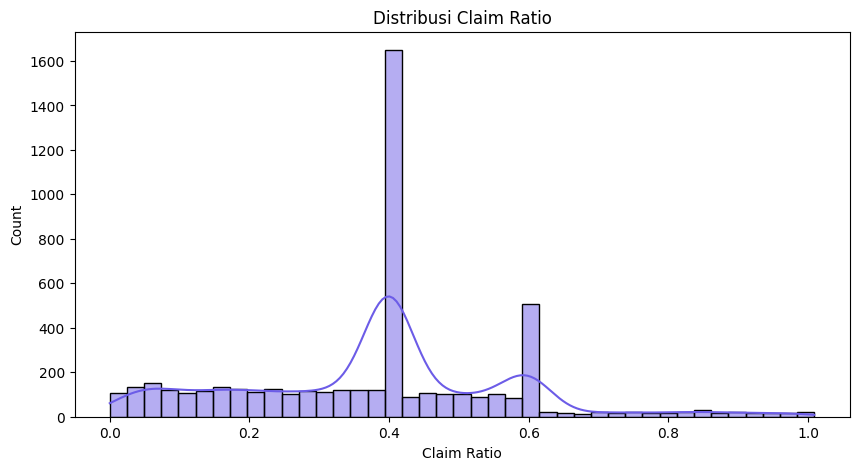

In [27]:
plt.figure(figsize=(10,5))
sns.histplot(df_modeling['Claim Ratio'], kde=True, color='#6C5CE7')
plt.title("Distribusi Claim Ratio")
plt.show()

Distribusi claim ratio menunjukkan pola yang tidak normal dan cenderung memiliki dua puncak utama di sekitar nilai 0.4 dan 0.6. Hal ini mengindikasikan adanya segmentasi alami dalam data berdasarkan tingkat risiko pelanggan.

Sebagian besar pelanggan memiliki claim ratio pada rentang 0.3 hingga 0.6, yang menunjukkan bahwa nilai klaim relatif sebanding dengan premi yang dibayarkan. Sementara itu, pelanggan dengan claim ratio tinggi (di atas 0.6) berpotensi memiliki risiko yang lebih tinggi karena nilai klaim yang mendekati atau melebihi premi.

Sebaliknya, pelanggan dengan claim ratio rendah cenderung lebih menguntungkan bagi perusahaan. Oleh karena itu, claim ratio dapat digunakan sebagai fitur penting dalam merepresentasikan tingkat risiko pelanggan dalam proses modeling.

##### Claim Ratio vs CLV

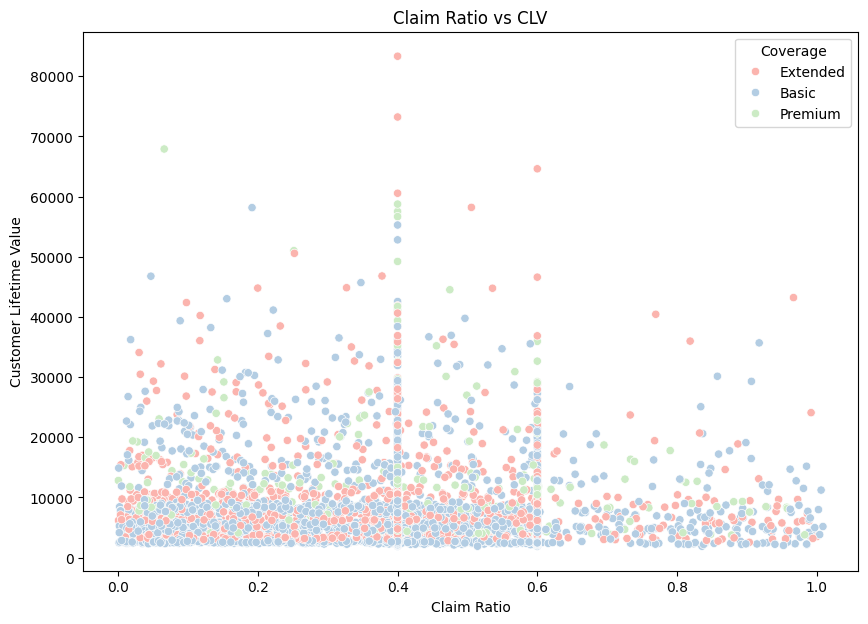

In [28]:
plt.figure(figsize=(10,7))
sns.scatterplot(
    x="Claim Ratio",
    y="Customer Lifetime Value",
    palette='Pastel1',
    hue="Coverage",
    data=df_modeling,
)
plt.title("Claim Ratio vs CLV")
plt.show()

Visualisasi antara claim ratio dan Customer Lifetime Value (CLV) menunjukkan bahwa tidak terdapat hubungan linear yang kuat antara keduanya. Nilai CLV tersebar pada berbagai tingkat claim ratio, baik pada nilai rendah maupun tinggi.

Hal ini mengindikasikan bahwa tingkat risiko yang direpresentasikan oleh claim ratio tidak secara langsung menentukan nilai pelanggan. Pelanggan dengan claim ratio tinggi (risiko tinggi) masih dapat memiliki CLV yang tinggi, kemungkinan karena mereka membayar premi yang lebih besar. Sebaliknya, pelanggan dengan claim ratio rendah tidak selalu memiliki CLV yang tinggi.

Selain itu, berdasarkan jenis coverage, terlihat bahwa pelanggan dengan coverage premium cenderung memiliki CLV yang lebih tinggi dibandingkan dengan coverage lainnya.

Dengan demikian, dapat disimpulkan bahwa CLV dipengaruhi oleh kombinasi beberapa faktor, dan claim ratio perlu digunakan bersama fitur lain untuk memberikan prediksi yang lebih akurat.

##### Mencari Tahu Risiko Pelanggan Terhadap Setiap Kolom Kategorikal

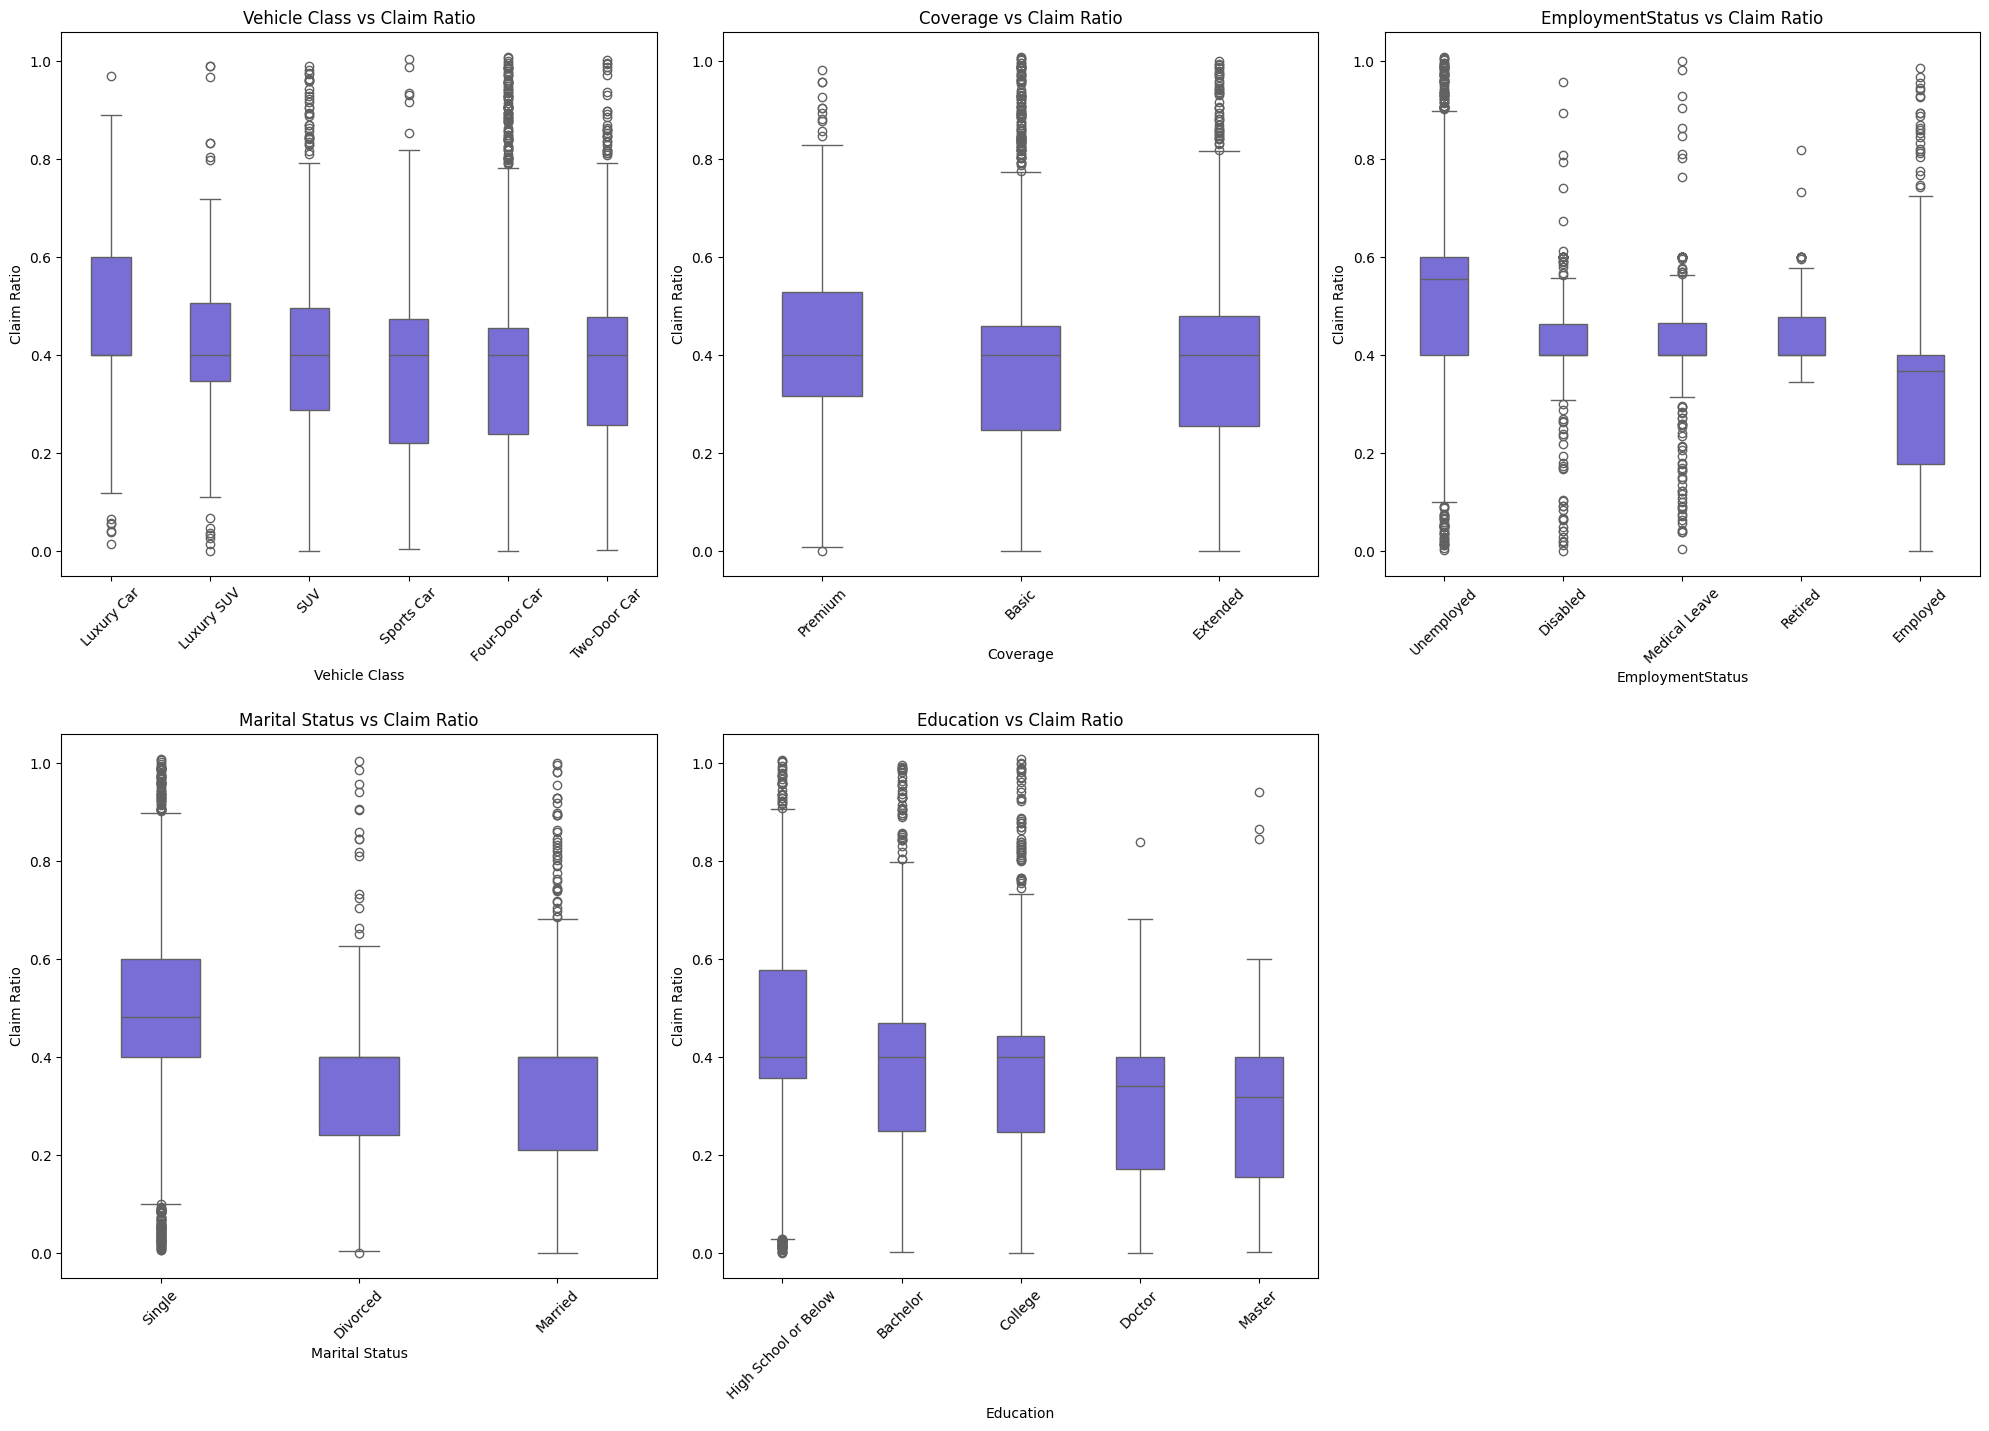

In [29]:
cat_cols = [
    "Vehicle Class",
    "Coverage",
    "EmploymentStatus",
    "Marital Status",
    "Education"
]

plt.figure(figsize=(20, 20))

for i, col in enumerate(cat_cols, 1):
    order = df_modeling.groupby(col)['Claim Ratio'].median().sort_values(ascending=False).index
    
    plt.subplot(3, 3, i)
    sns.boxplot(x=col, y="Claim Ratio", data=df_modeling, color='#6C5CE7', order=order, width=0.4)
    plt.xticks(rotation=45)
    plt.title(f"{col} vs Claim Ratio")

plt.tight_layout()
plt.show()

Untuk memahami bagaimana tingkat risiko (claim ratio) berbeda antar segmen pelanggan, dilakukan analisis terhadap beberapa variabel kategorikal.

Hasil menunjukkan bahwa jenis coverage memiliki pengaruh paling signifikan terhadap claim ratio, di mana pelanggan dengan coverage yang lebih tinggi cenderung memiliki claim ratio yang lebih besar. Hal ini sejalan dengan logika bisnis, karena coverage yang lebih luas memungkinkan lebih banyak klaim yang dapat diajukan.

Sementara itu, variabel lain seperti vehicle class, employment status, marital status, dan education menunjukkan perbedaan yang relatif kecil dengan distribusi yang saling tumpang tindih, sehingga pengaruhnya terhadap claim ratio cenderung lebih lemah.

Dengan demikian, dapat disimpulkan bahwa faktor utama yang memengaruhi tingkat risiko pelanggan adalah karakteristik produk (coverage), dibandingkan dengan faktor demografis.

#### Annual Premium

Untuk menyesuaikan skala antara premi dan Customer Lifetime Value (CLV) yang bersifat jangka panjang, dilakukan transformasi terhadap variabel Monthly Premium Auto menjadi annual premium.

Hal ini dilakukan dengan mengalikan nilai premi bulanan dengan 12, sehingga diperoleh estimasi premi tahunan yang lebih representatif dalam konteks nilai lifetime pelanggan.

Meskipun transformasi ini tidak menambah informasi baru secara statistik, penggunaan annual premium memberikan interpretasi yang lebih relevan secara bisnis, karena CLV menggambarkan nilai pelanggan dalam jangka waktu yang lebih panjang. Oleh karena itu, annual premium digunakan sebagai salah satu fitur tambahan dalam proses modeling.

In [30]:
df_modeling["Annual Premium"] = df_modeling["Monthly Premium Auto"] * 12

##### Distribusi Annual Premium

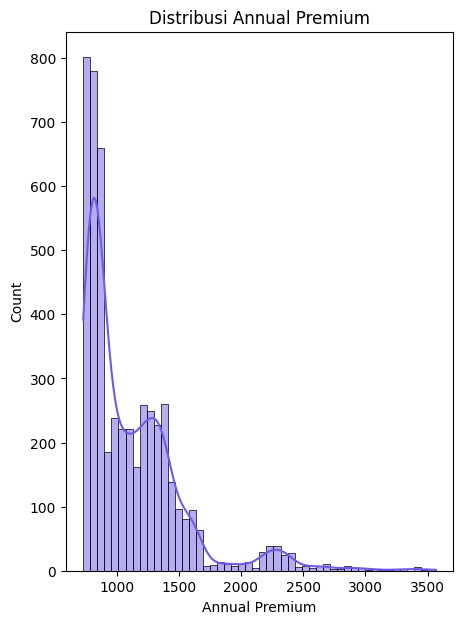

In [31]:
plt.figure(figsize=(5, 7))
sns.histplot(
    df_modeling["Annual Premium"],
    kde=True,
    color='#6C5CE7'
)
plt.title("Distribusi Annual Premium")
plt.show()

##### Korelasi dengan CLV

In [32]:
df_modeling[["Annual Premium", "Customer Lifetime Value"]].corr()

,Annual Premium,Customer Lifetime Value
Annual Premium,1.00000,0.41709
Customer Lifetime Value,0.41709,1.00000


Distribusi annual premium menunjukkan pola yang right-skewed, di mana sebagian besar pelanggan memiliki premi tahunan pada rentang rendah hingga menengah, sementara hanya sebagian kecil pelanggan yang memiliki premi tinggi.

Selain itu, terdapat korelasi positif moderat antara annual premium dan Customer Lifetime Value (CLV), dengan nilai korelasi sekitar 0.417. Hal ini menunjukkan bahwa pelanggan dengan premi yang lebih tinggi cenderung memiliki nilai CLV yang lebih tinggi.

Namun, karena korelasi tersebut tidak terlalu kuat, dapat disimpulkan bahwa CLV tidak hanya dipengaruhi oleh premi, tetapi juga oleh faktor lain seperti perilaku klaim dan karakteristik pelanggan. Oleh karena itu, annual premium digunakan sebagai salah satu fitur tambahan yang relevan dalam proses modeling.

#### Premium x Claim Ratio

Untuk menangkap hubungan antara nilai premi dan tingkat risiko pelanggan, dibuat fitur interaksi berupa Premium x Claim Ratio

Fitur ini bertujuan untuk merepresentasikan kombinasi antara nilai pelanggan (premium) dan tingkat risiko (claim ratio) secara simultan. Dengan adanya fitur ini, model diharapkan dapat membedakan karakteristik pelanggan yang memiliki tingkat risiko yang sama namun dengan nilai premi yang berbeda.

Sebagai contoh, pelanggan dengan claim ratio tinggi dan premi tinggi memiliki profil yang berbeda dibandingkan dengan pelanggan dengan claim ratio tinggi namun premi rendah. Oleh karena itu, fitur interaksi ini diharapkan dapat membantu model dalam menangkap pola yang lebih kompleks dalam data.

In [33]:
df_modeling["Premium x Claim Ratio"] = df_modeling["Annual Premium"] * df_modeling["Claim Ratio"]

##### Distribusi Premium x Claim Ratio

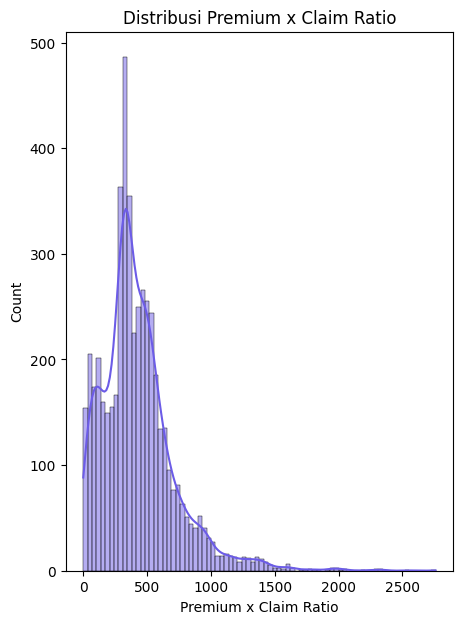

In [34]:
plt.figure(figsize=(5, 7))
sns.histplot(
    df_modeling["Premium x Claim Ratio"],
    kde=True,
    color='#6C5CE7'
)
plt.title("Distribusi Premium x Claim Ratio")
plt.show()

##### Persebaran Premium x Claim Ratio

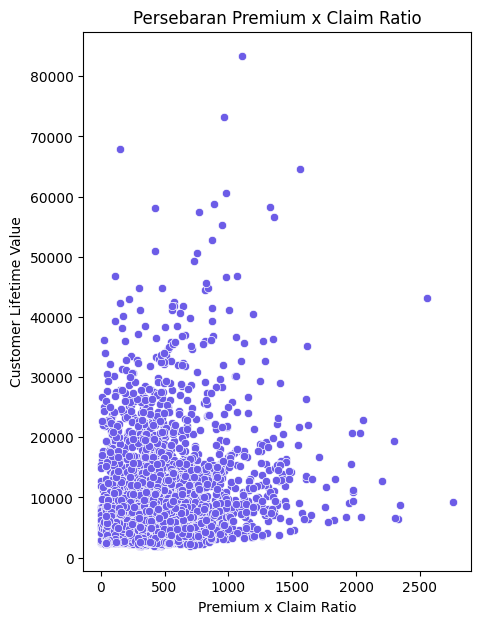

In [35]:
plt.figure(figsize=(5, 7))
sns.scatterplot(
    x = "Premium x Claim Ratio",
    y = "Customer Lifetime Value",
    data=df_modeling,
    color='#6C5CE7'
)
plt.title("Persebaran Premium x Claim Ratio")
plt.show()

Korelasi Antara Premium x Claim Ratio dan Customer Lifetime Value

In [36]:
df_modeling[["Premium x Claim Ratio", "Customer Lifetime Value"]].corr()

,Premium x Claim Ratio,Customer Lifetime Value
Premium x Claim Ratio,1.000000,0.211937
Customer Lifetime Value,0.211937,1.000000


Distribusi Premium x Claim Ratio menunjukkan pola right-skewed, di mana sebagian besar pelanggan memiliki nilai kombinasi premi dan klaim yang relatif rendah, sementara hanya sebagian kecil yang memiliki nilai tinggi.

Namun, berdasarkan analisis hubungan dengan Customer Lifetime Value (CLV), tidak terlihat adanya pola hubungan linear yang kuat antara Premium x Claim Ratio dan CLV. Hal ini juga didukung oleh nilai korelasi yang relatif rendah, yaitu sekitar 0.21.

Temuan ini menunjukkan bahwa kombinasi antara premi dan tingkat klaim tidak secara langsung menentukan nilai pelanggan. Dibandingkan dengan fitur annual premium, fitur ini memiliki pengaruh yang lebih lemah terhadap CLV.

Meskipun demikian, fitur ini tetap dapat digunakan sebagai fitur tambahan dalam model untuk membantu menangkap pola non-linear yang mungkin tidak terlihat secara langsung.

#### Kesimpulan Setelah Feature Engineering

Setelah dilakukan penambahan beberapa fitur baru, dilakukan evaluasi untuk melihat hubungan antara fitur-fitur tersebut dengan Customer Lifetime Value (CLV).

Berdasarkan hasil analisis, tidak ditemukan fitur dengan korelasi yang sangat tinggi terhadap CLV. Hal ini merupakan kondisi yang umum dalam data dunia nyata, di mana nilai target sering kali dipengaruhi oleh kombinasi berbagai faktor, bukan oleh satu variabel tunggal.

Fitur seperti annual premium menunjukkan korelasi yang relatif lebih tinggi dibandingkan fitur lainnya, sehingga dapat dianggap sebagai salah satu driver utama CLV. Sementara itu, fitur lain seperti claim ratio dan fitur interaksi tetap digunakan untuk membantu model dalam menangkap pola non-linear yang mungkin tidak terlihat dari analisis korelasi sederhana.

##### Hasil Eksplorasi Pengaruh Terhadap CLV

Berdasarkan hasil eksplorasi data, fitur yang paling berpengaruh terhadap Customer Lifetime Value (CLV) adalah annual premium, yang menunjukkan korelasi paling tinggi dibandingkan fitur lainnya. Hal ini menunjukkan bahwa nilai premi merupakan faktor utama dalam menentukan nilai pelanggan.

Selain itu, fitur yang berkaitan dengan klaim seperti total claim amount dan claim ratio juga memberikan kontribusi, meskipun pengaruhnya tidak sekuat premium. Fitur-fitur ini lebih merepresentasikan tingkat risiko pelanggan dibandingkan nilai yang dihasilkan.

Untuk fitur kategorikal, variabel seperti coverage dan vehicle class menunjukkan pengaruh tidak langsung terhadap CLV, kemungkinan melalui keterkaitannya dengan besaran premi.

Namun demikian, perlu dicatat bahwa analisis ini didasarkan pada hubungan linear, sehingga pada tahap modeling, fitur-fitur lain tetap digunakan untuk memungkinkan model menangkap pola non-linear yang lebih kompleks.

### Data Cleaning

#### Drop Monthly Premium Auto

Dikarenakan kita sudah melakukan feature engineering dengan menambahkan kolom Annual Premium, maka Monthly Premium Auto menjadi redundant, sehingga kita drop saja fitur tersebut.

In [37]:
df_modeling = df_modeling.drop('Monthly Premium Auto', axis=1)

Sebelumnya, kita sudah melakukan drop duplicates, sehingga tidak diperlukan lagi di tahap ini. 

Selain itu juga, karena kita tidak menemukan hubungan yang linear terhadap Customer Lifetime Value, tidak ada fitur kategorikal yang kita drop. Karena, fitur-fitur tersebut memengaruhi nilai Customer Lifetime Value.

## Modeling

### Train-Test Split

In [38]:
# Menentukan fitur yang akan digunakan

X = df_modeling.drop("Customer Lifetime Value", axis=1)
y = df_modeling["Customer Lifetime Value"]

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


### Encoding

In [40]:
X_train.head()

,Vehicle Class,Coverage,Renew Offer Type,EmploymentStatus,Marital Status,Education,Number of Policies,Total Claim Amount,Income,Claim Ratio,Annual Premium,Premium x Claim Ratio
1055,Four-Door Car,Basic,Offer4,Employed,Married,College,7.0,307.200000,23840.0,0.400000,768.0,307.200000
470,Four-Door Car,Extended,Offer2,Employed,Married,Master,1.0,391.210704,85751.0,0.350547,1116.0,391.210704
2561,Four-Door Car,Basic,Offer1,Unemployed,Single,Bachelor,3.0,525.600000,0.0,0.600000,876.0,525.600000
1323,Two-Door Car,Basic,Offer2,Employed,Single,College,2.0,231.201886,60920.0,0.301044,768.0,231.201886
4373,Four-Door Car,Basic,Offer3,Medical Leave,Married,College,1.0,312.000000,17658.0,0.400000,780.0,312.000000


#### One-Hot Encoding

Pada tahap preprocessing, seluruh fitur kategorikal diubah menjadi format numerik menggunakan One-Hot Encoding. Metode ini dipilih karena variabel kategorikal pada dataset tidak memiliki hubungan ordinal yang konsisten, sehingga tidak tepat jika diperlakukan sebagai variabel berurutan.

Proses encoding dilakukan dengan mempelajari kategori hanya dari data latih (X_train), lalu hasil transformasinya diterapkan pada data uji (X_test) untuk menghindari data leakage.

In [41]:
from sklearn.preprocessing import OneHotEncoder

cat_cols = X_train.select_dtypes(include="string").columns.tolist()
oneHotEncoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_train_cat = oneHotEncoder.fit_transform(X_train[cat_cols])
X_test_cat = oneHotEncoder.transform(X_test[cat_cols])

In [42]:
encoded = oneHotEncoder.get_feature_names_out(cat_cols)
print(encoded)

['Vehicle Class_Four-Door Car' 'Vehicle Class_Luxury Car'
 'Vehicle Class_Luxury SUV' 'Vehicle Class_SUV' 'Vehicle Class_Sports Car'
 'Vehicle Class_Two-Door Car' 'Coverage_Basic' 'Coverage_Extended'
 'Coverage_Premium' 'Renew Offer Type_Offer1' 'Renew Offer Type_Offer2'
 'Renew Offer Type_Offer3' 'Renew Offer Type_Offer4'
 'EmploymentStatus_Disabled' 'EmploymentStatus_Employed'
 'EmploymentStatus_Medical Leave' 'EmploymentStatus_Retired'
 'EmploymentStatus_Unemployed' 'Marital Status_Divorced'
 'Marital Status_Married' 'Marital Status_Single' 'Education_Bachelor'
 'Education_College' 'Education_Doctor' 'Education_High School or Below'
 'Education_Master']


In [43]:
X_train_cat_df = pd.DataFrame(
    X_train_cat,
    columns=encoded,
    index=X_train.index
)

In [44]:
X_test_cat_df = pd.DataFrame(
    X_test_cat,
    columns=encoded,
    index=X_test.index
)

### Scaling

Proses scaling dilakukan untuk menyamakan skala antar fitur numerik. Hal ini penting karena beberapa algoritma machine learning, seperti Linear Regression, sensitif terhadap perbedaan skala antar variabel.

Tanpa scaling, fitur dengan nilai yang lebih besar dapat mendominasi proses pembelajaran model, meskipun secara bisnis belum tentu lebih penting.

In [45]:
from sklearn.preprocessing import StandardScaler

num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train[num_cols])
X_test_num = scaler.transform(X_test[num_cols])

In [46]:
# Gabungkan hasil yang telah diencode dan discale

X_train_final = np.concatenate([X_train_num, X_train_cat], axis=1)
X_test_final = np.concatenate([X_test_num, X_test_cat], axis=1)

### Modeling

Untuk modeling dataset CLV ini, kita menggunakan 3 jenis model regression:
1. Linear Regression
2. Random Forest Regressor
3. XGBoost

**Pemilihan Metric Evaluasi**
Dalam mengevaluasi model prediksi Customer Lifetime Value (CLV) asuransi kendaraan ini, kami menggunakan lima metrik utama untuk mendapatkan gambaran performa yang menyeluruh, baik dari sisi akurasi bisnis maupun risiko teknis.
1. Mean Absolute Error (MAE): Rata-rata selisih absolut antara nilai prediksi dan nilai asli dalam satuan mata uang. Ini menunjukkan seberapa besar kesalahan prediksi kita secara riil.
2. Mean Absolute Percentage Error (MAPE): Rata-rata persentase kesalahan prediksi. Metrik ini memberikan gambaran akurasi dalam skala relatif (persentase) terhadap nilai aslinya.
3. Mean Squared Error (MSE): Rata-rata dari kuadrat kesalahan. Metrik ini memberikan beban yang sangat berat pada kesalahan yang besar
4. Root Mean Squared Error (RMSE): Akar kuadrat dari MSE. Metrik ini mengembalikan nilai error ke satuan mata uang untuk melihat seberapa besar deviasi standar dari prediksi kita.
5. R-Squared: Koefisien determinasi yang menunjukkan seberapa baik model dapat menjelaskan variasi dalam data (skala 0 sampai 1).

Pemilihan kombinasi kelima metrik ini sangat krusial dalam konteks asuransi karena alasan berikut:
1. Interpretasi Bisnis (MAE & MAPE):
Tim manajemen dan pemasaran membutuhkan angka yang mudah dipahami. Dengan MAPE 10.28%, kita bisa dengan yakin menyatakan bahwa akurasi model mencapai ~90%. Sementara MAE `$1,461` memberikan angka nyata bagi tim keuangan untuk memperhitungkan margin keuntungan.
2. Manajemen Risiko (MSE & RMSE):
Data CLV asuransi seringkali memiliki nasabah bernilai sangat tinggi (Whales). RMSE yang lebih tinggi dari MAE (`$4,000` vs `$1,461`) memperingatkan kita bahwa model masih memiliki risiko kesalahan saat memprediksi nasabah dengan profil ekstrim. Ini penting agar perusahaan tetap waspada pada segmen nasabah paling bernilai.
3. Validasi Kualitas (R-Squared):
Skor 0.66 membuktikan bahwa model ini "cerdas" dan mampu menangkap 66% pola perilaku nasabah. Ini jauh lebih baik daripada model linear yang gagal, sekaligus memberikan bukti ilmiah bahwa variabel yang kita gunakan (seperti jumlah polis dan jenis kendaraan) adalah fitur yang valid.







#### Linear Regression

Linear Regression digunakan untuk mencari hubungan linear antara fitur dan target. Untuk kasus ini, Linear Regression adalah model yang digunakan sebagai baseline, dan untuk melihat apakah hubungan linear cukup terhadap dataset ini.


In [47]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train_final, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [48]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error, r2_score

y_pred = model.predict(X_test_final)

mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

##### Evaluation

In [49]:
print("="*40)
print(f"{'EVALUASI MODEL LINEAR REGRESSION':^40}")
print("="*40)
print(f"{'Metric':<15} | {'Value':<20}")
print("-"*40)
print(f"{'MAE':<15} | ${mae:,.2f}")
print(f"{'MAPE':<15} | {mape*100:.2f}%")
print(f"{'MSE':<15} | {mse:,.2f}")
print(f"{'RMSE':<15} | ${rmse:,.2f}")
print(f"{'R-Squared':<15} | {r2:.4f}")
print("="*40)
print(f"Akurasi Model: {(1-mape)*100:.2f}%")
print("="*40)

    EVALUASI MODEL LINEAR REGRESSION    
Metric          | Value               
----------------------------------------
MAE             | $3,860.14
MAPE            | 62.57%
MSE             | 40,312,523.56
RMSE            | $6,349.21
R-Squared       | 0.1530
Akurasi Model: 37.43%


Model Linear Regression digunakan sebagai baseline untuk memprediksi Customer Lifetime Value (CLV). Hasil evaluasi menunjukkan bahwa model memiliki performa yang masih rendah, dengan nilai R² sebesar 0.15, yang berarti model hanya mampu menjelaskan sekitar 15% variasi pada data target.

Nilai MAE dan RMSE yang relatif tinggi menunjukkan bahwa prediksi model masih memiliki error yang cukup besar. Hal ini mengindikasikan bahwa hubungan antara fitur dan CLV kemungkinan bersifat non-linear dan kompleks, sehingga tidak dapat ditangkap dengan baik oleh model linear sederhana.

Oleh karena itu, diperlukan model yang lebih kompleks seperti Random Forest untuk menangkap pola non-linear dalam data.

#### Random Forest

Dikarenakan pada dataset ini tidak ada hubungan linear terhadap fitur dan target, yaitu Customer Lifetime Value, Linear Regression tidak bekerja dengan baik. Sehingga kita butuh menggunakan model yang bisa menangkap hubungan non-linear, serta robust terhadap outlier, dan tidak butuh asumsi distribusi. Random Forest adalah pilihan model yang cocok untuk kasus ini.

In [50]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_final, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [51]:
y_pred = rf.predict(X_test_final)

mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

##### Evaluation

In [52]:
print("="*40)
print(f"{'EVALUASI MODEL RANDOM FOREST':^40}")
print("="*40)
print(f"{'Metric':<15} | {'Value':<20}")
print("-"*40)
print(f"{'MAE':<15} | ${mae:,.2f}")
print(f"{'MAPE':<15} | {mape*100:.2f}%")
print(f"{'MSE':<15} | {mse:,.2f}")
print(f"{'RMSE':<15} | ${rmse:,.2f}")
print(f"{'R-Squared':<15} | {r2:.4f}")
print("="*40)
print(f"Akurasi Model: {(1-mape)*100:.2f}%")
print("="*40)

      EVALUASI MODEL RANDOM FOREST      
Metric          | Value               
----------------------------------------
MAE             | $1,641.21
MAPE            | 12.71%
MSE             | 16,649,628.26
RMSE            | $4,080.40
R-Squared       | 0.6502
Akurasi Model: 87.29%


Model Random Forest menunjukkan peningkatan performa yang signifikan dibandingkan Linear Regression. Nilai R² meningkat dari sekitar 0.15 menjadi 0.65, yang menunjukkan bahwa model mampu menangkap pola yang lebih kompleks dalam data.

Penurunan nilai MAE dan RMSE juga menunjukkan bahwa kesalahan prediksi menjadi jauh lebih kecil. Hal ini mengindikasikan bahwa hubungan antara fitur dan Customer Lifetime Value (CLV) bersifat non-linear dan tidak dapat ditangkap dengan baik oleh model linear sederhana.

Dengan demikian, Random Forest menjadi model yang lebih sesuai untuk digunakan dalam kasus ini.

#### XGBoost

Sebagai tahap akhir, kami menggunakan XGBoost (Extreme Gradient Boosting), yang merupakan algoritma state-of-the-art dalam kompetisi data science. XGBoost bekerja dengan cara memperbaiki kesalahan dari pohon-pohon sebelumnya secara berurutan (boosting).

In [53]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5
)

xgb_model.fit(X_train_final, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [54]:
y_pred_xgb = xgb_model.predict(X_test_final)

mae = mean_absolute_error(y_test, y_pred_xgb)
mape = mean_absolute_percentage_error(y_test, y_pred_xgb)
mse = mean_squared_error(y_test, y_pred_xgb)
rmse = root_mean_squared_error(y_test, y_pred_xgb)
r2 = r2_score(y_test, y_pred_xgb)

##### Evaluation

In [55]:
print("="*40)
print(f"{'EVALUASI MODEL XGBOOST':^40}")
print("="*40)
print(f"{'Metric':<15} | {'Value':<20}")
print("-"*40)
print(f"{'MAE':<15} | ${mae:,.2f}")
print(f"{'MAPE':<15} | {mape*100:.2f}%")
print(f"{'MSE':<15} | {mse:,.2f}")
print(f"{'RMSE':<15} | ${rmse:,.2f}")
print(f"{'R-Squared':<15} | {r2:.4f}")
print("="*40)
print(f"Akurasi Model: {(1-mape)*100:.2f}%")
print("="*40)

         EVALUASI MODEL XGBOOST         
Metric          | Value               
----------------------------------------
MAE             | $1,658.62
MAPE            | 14.37%
MSE             | 14,963,239.10
RMSE            | $3,868.23
R-Squared       | 0.6856
Akurasi Model: 85.63%


Model XGBoost menunjukkan performa terbaik dibandingkan model lainnya. Nilai R² meningkat menjadi sekitar 0.69, yang menunjukkan bahwa model mampu menjelaskan hampir 69% variasi pada Customer Lifetime Value (CLV).

Selain itu, nilai RMSE yang lebih rendah dibandingkan Random Forest menunjukkan bahwa model memiliki kemampuan yang lebih baik dalam mengurangi kesalahan prediksi, khususnya pada nilai-nilai ekstrem.

Hal ini mengindikasikan bahwa pendekatan boosting yang digunakan oleh XGBoost lebih efektif dalam menangkap pola kompleks dan non-linear dalam data dibandingkan metode bagging seperti Random Forest.

Berdasarkan hasil evaluasi di atas, model XGBoost merupakan model terbaik untuk kasus ini, tetapi perlu diperhatikan Minimum Absolute Error (MAE) pada model tersebut. Error ini merepresentasikan error di dunia nyata. Pada model ini didapatkan hasilnya adalah kurang lebih `$1658`, yang artinya error prediksi CLV adalah sekitar nilai tersebut:
- Jika CLV rata-rata pelanggan bernilai `$20.000`, error ini kecil.
- Jika CLV rata-rata pelanggan bernila `$3.000`, error ini menjadi besar

Hal ini terjadi karena terdapat skewness terhadap CLV, yang sebelumnya telah kita eksplorasi, yaitu skewed-right. Sehingga kita perlu normalisasi nilai CLV.

In [57]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

In [58]:
xgb_model.fit(X_train_final, y_train_log)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [59]:
y_pred_log = xgb_model.predict(X_test_final)

y_pred_log_dollars = np.expm1(y_pred_log)

mae = mean_absolute_error(y_test, y_pred_log_dollars)
mape = mean_absolute_percentage_error(y_test, y_pred_log_dollars)
mse = mean_squared_error(y_test, y_pred_log_dollars)
rmse = root_mean_squared_error(y_test, y_pred_log_dollars)
r2 = r2_score(y_test, y_pred_log_dollars)

In [60]:
print("="*40)
print(f"{'EVALUASI MODEL XGBOOST (NORMALIZED)':^40}")
print("="*40)
print(f"{'Metric':<15} | {'Value':<20}")
print("-"*40)
print(f"{'MAE':<15} | ${mae:,.2f}")
print(f"{'MAPE':<15} | {mape*100:.2f}%")
print(f"{'MSE':<15} | {mse:,.2f}")
print(f"{'RMSE':<15} | ${rmse:,.2f}")
print(f"{'R-Squared':<15} | {r2:.4f}")
print("="*40)
print(f"Akurasi Model: {(1-mape)*100:.2f}%")
print("="*40)

  EVALUASI MODEL XGBOOST (NORMALIZED)   
Metric          | Value               
----------------------------------------
MAE             | $1,461.74
MAPE            | 10.28%
MSE             | 16,001,595.61
RMSE            | $4,000.20
R-Squared       | 0.6638
Akurasi Model: 89.72%


In [61]:
df_modeling["Customer Lifetime Value"].mean()

np.float64(8059.483177952287)

#### Hyperparameter Tuning

Dalam tahap optimasi model XGBoost, terdapat tiga metode umum untuk mencari parameter terbaik: Grid Search, Randomized Search, dan Bayesian Optimization. Untuk proyek ini, kami memilih Randomized Search CV dengan pertimbangan teknis berikut:
1. Apa itu Randomized Search CV?
Randomized Search adalah metode optimasi yang tidak menguji seluruh kombinasi parameter yang ada, melainkan mengambil sampel secara acak dari ruang pencarian (search space) yang telah ditentukan. Berbeda dengan Grid Search yang mencoba setiap kemungkinan (melelahkan dan lambat), Randomized Search melakukan pencarian yang lebih cerdas dan efisien.

2. Mengapa Memilih Randomized Search?
- Efisiensi Waktu & Komputasi: Algoritma XGBoost memiliki banyak parameter kompleks (seperti max_depth, learning_rate, dan gamma). Menguji semua kombinasi akan memakan waktu berjam-jam. Randomized Search mampu menemukan hasil yang mendekati optimal dalam waktu yang jauh lebih singkat.
- Efektivitas Penemuan Parameter: Penelitian menunjukkan bahwa dalam ruang dimensi tinggi, hanya beberapa parameter yang benar-benar berpengaruh signifikan terhadap performa model. Randomized Search sangat ahli dalam menemukan "titik manis" (sweet spot) ini tanpa membuang waktu pada parameter yang kurang relevan.
- Menghindari Overfitting (Cross-Validation): Dengan menggunakan 3-Fold Cross-Validation, metode ini memastikan bahwa parameter yang terpilih bukan hanya "kebetulan" bagus pada data tertentu, melainkan stabil saat dihadapkan pada data yang belum pernah dilihat sebelumnya.

Pada dataset Customer Lifetime Value (CLV) yang kita miliki, data cenderung memiliki variasi yang tinggi (noise). Randomized Search membantu kita menemukan parameter yang membuat model tetap general (tidak terlalu kaku/overfit) sehingga prediksi untuk nasabah baru tetap akurat dan reliabel.



##### Random Search

In [62]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 300, 500, 1000],
    'max_depth': [3, 5, 7, 9],            
    'learning_rate': [0.01, 0.05, 0.1],   
    'subsample': [0.7, 0.8, 0.9],        
    'colsample_bytree': [0.7, 0.8, 0.9],  
    'gamma': [0, 0.1, 0.5, 1]      
}

xgb_tune = xgb.XGBRegressor(objective="reg:squarederror", random_state=42)

random_search = RandomizedSearchCV(
    estimator=xgb_tune,
    param_distributions=param_grid,
    n_iter=25,          
    scoring='r2', 
    cv=3, 
    verbose=1, 
    n_jobs=-1
)

random_search.fit(X_train_final, y_train_log)

print("Best Parameters:", random_search.best_params_)
print("Best R2 Score (Log Scale):", random_search.best_score_)

Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best Parameters: {'subsample': 0.9, 'n_estimators': 1000, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.8}
Best R2 Score (Log Scale): 0.8993177011607324


In [63]:
best_model = random_search.best_estimator_

y_pred_log_rs = best_model.predict(X_test_final)
y_pred_dollars = np.expm1(y_pred_log)

In [64]:
mae = mean_absolute_error(y_test, y_pred_log_dollars)
mape = mean_absolute_percentage_error(y_test, y_pred_log_dollars)
mse = mean_squared_error(y_test, y_pred_log_dollars)
rmse = root_mean_squared_error(y_test, y_pred_log_dollars)
r2 = r2_score(y_test, y_pred_log_dollars)

In [65]:
print("="*40)
print(f"{'EVALUASI MODEL XGBOOST (TUNED)':^40}")
print("="*40)
print(f"{'Metric':<15} | {'Value':<20}")
print("-"*40)
print(f"{'MAE':<15} | ${mae:,.2f}")
print(f"{'MAPE':<15} | {mape*100:.2f}%")
print(f"{'MSE':<15} | {mse:,.2f}")
print(f"{'RMSE':<15} | ${rmse:,.2f}")
print(f"{'R-Squared':<15} | {r2:.4f}")
print("="*40)
print(f"Akurasi Model: {(1-mape)*100:.2f}%")
print("="*40)

     EVALUASI MODEL XGBOOST (TUNED)     
Metric          | Value               
----------------------------------------
MAE             | $1,461.74
MAPE            | 10.28%
MSE             | 16,001,595.61
RMSE            | $4,000.20
R-Squared       | 0.6638
Akurasi Model: 89.72%


Berdasarkan perbandingan antara model XGBoost Baseline (Log-Transformed) dan XGBoost Tuned (Randomized Search), terlihat bahwa skor evaluasi (MAE, MAPE, RMSE, dan R2) menunjukkan hasil yang identik. Fenomena ini memberikan beberapa kesimpulan teknis yang penting bagi integritas model:
1. Konvergensi Parameter Default: XGBoost memiliki parameter default yang sangat kuat. Dalam kasus dataset ini, parameter bawaan tersebut ternyata sudah mencapai titik optimal atau "puncak matematis" untuk pola data yang tersedia.
2. Kualitas Data (Feature Dominance): Dominasi fitur tertentu (seperti Number of Policies yang memiliki importance > 0.50) sangat kuat sehingga perubahan kecil pada hyperparameter (seperti learning_rate atau max_depth) tidak lagi memberikan perubahan signifikan pada prediksi akhir.
3. Data Ceiling (Batas Maksimal Data): Dengan akurasi model sebesar 89.72%, model ini kemungkinan besar telah mencapai "batas maksimal" informasi yang bisa diekstrak dari 5.000an baris data yang tersedia. Sisa error sebesar ~10% kemungkinan merupakan irreducible error (variabel acak di dunia nyata yang tidak tercatat dalam dataset).

#### Feature Importance

Feature Importance adalah teknik untuk mengukur seberapa besar kontribusi atau pengaruh setiap variabel input (fitur) terhadap kemampuan prediksi model. Dalam model berbasis tree, skor ini biasanya dihitung berdasarkan seberapa sering sebuah fitur digunakan untuk membagi data (split) dan seberapa banyak fitur tersebut meningkatkan akurasi model secara keseluruhan.

Tujuan Feature Importance dalam CLV:
1. Transparansi Model: Mengubah model "kotak hitam" (black box) menjadi informasi yang dapat dimengerti, sehingga kita tahu alasan di balik prediksi nilai pelanggan.
2. Efisiensi Bisnis: Membantu manajemen fokus pada faktor-faktor yang paling berpengaruh secara signifikan terhadap profitabilitas perusahaan.
3. Validasi Domain: Memastikan bahwa model mempelajari pola yang masuk akal secara bisnis (misalnya: apakah premi dan jumlah polis benar-benar berpengaruh?).

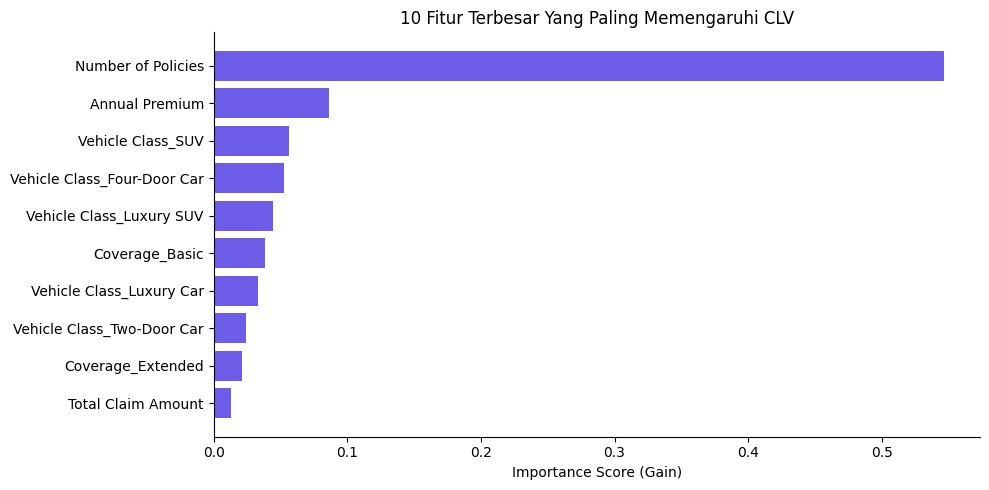

In [90]:
import matplotlib.pyplot as plt
import numpy as np

all_feature_names = num_cols + list(encoded)

importances = best_model.feature_importances_

indices = np.argsort(importances)[-10:] 

plt.figure(figsize=(10, 5))
plt.barh(range(len(indices)), importances[indices], color='#6C5CE7', align='center')
plt.yticks(range(len(indices)), [all_feature_names[i] for i in indices])
plt.xlabel('Importance Score (Gain)')
plt.title('10 Fitur Terbesar Yang Paling Memengaruhi CLV')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


Berdasarkan visualisasi di atas, berikut adalah temuan utama mengenai faktor pendorong Customer Lifetime Value (CLV):
1. Dominasi Jumlah Polis (Number of Policies):
   Fitur ini merupakan prediktor paling kuat dengan skor kepentingan jauh di atas fitur lainnya. Hal ini menunjukkan bahwa strategi multi-policy bundling (nasabah memiliki lebih dari satu polis) adalah faktor kunci yang meningkatkan nilai ekonomi pelanggan secara signifikan bagi perusahaan.
2. Segmen Kendaraan (SUV & Four-Door Car):
Tipe kendaraan SUV dan Four-Door Car muncul sebagai penggerak nilai yang utama. Ini mengindikasikan bahwa pemilik kendaraan keluarga atau kendaraan utilitas cenderung memiliki loyalitas atau nilai premi yang lebih stabil dibandingkan segmen lainnya.
3. Kapasitas Premi (Monthly Premium Auto):
Jumlah premi bulanan tetap menjadi faktor penting, namun menariknya, model menunjukkan bahwa loyalitas (jumlah polis) jauh lebih berharga daripada sekadar nominal premi yang tinggi di satu polis saja.
4. Jenis Cakupan (Coverage_Basic):
Fakta bahwa cakupan dasar (basic) masuk dalam jajaran fitur teratas menunjukkan bahwa mayoritas nilai portofolio kita saat ini terkunci pada produk entry-level, yang memberikan peluang besar untuk strategi upselling.


#### Perbandingan Performa dari Seluruh Model yang dipakai

In [92]:
data_comparison = {
    'Model': ["Linear Regression", "Random Forest", "XGBoost (Normalized and Tuned)"],
    "MAE": [3860.13, 1641.20, 1461.74],
    "MAPE (%)": [62.57, 20.3, 10.28],
    'MSE': [40312523, 16649628, 16001595],
    'RMSE': [6349.21, 4080.39, 4000.20],
    'R-Squared': [0.1530, 0.6501, 0.6638]
}

df_compare = pd.DataFrame(data_comparison)
df_compare

,Model,MAE,MAPE (%),MSE,RMSE,R-Squared
0,Linear Regression,3860.13,62.57,40312523,6349.21,0.1530
1,Random Forest,1641.20,20.30,16649628,4080.39,0.6501
2,XGBoost (Normalized and Tuned),1461.74,10.28,16001595,4000.20,0.6638


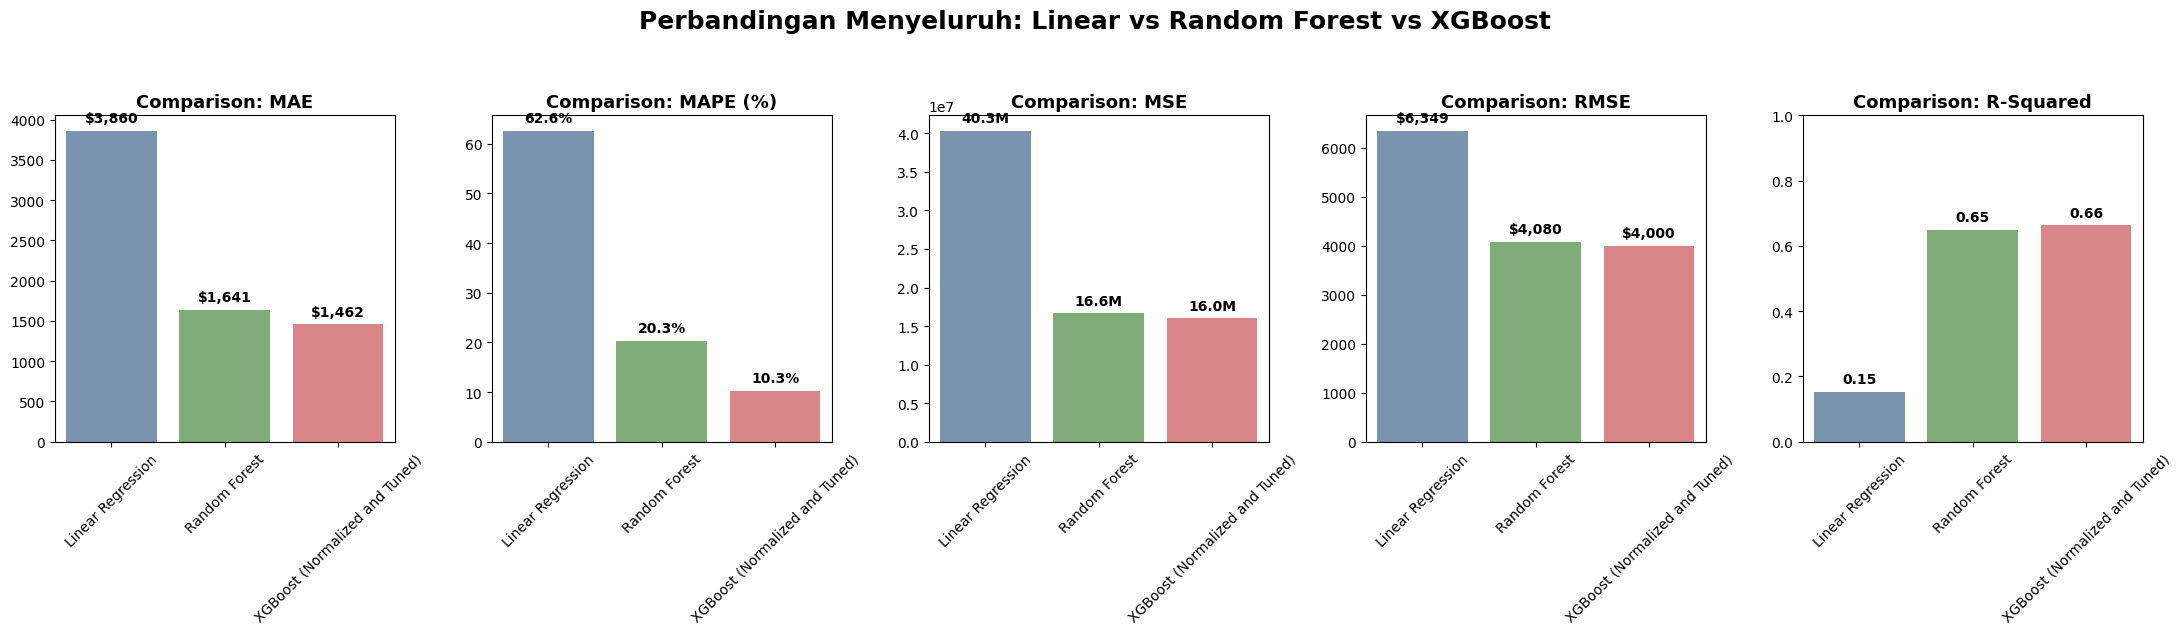

In [93]:
metrics = ['MAE', 'MAPE (%)', 'MSE', 'RMSE', 'R-Squared']
colors = ['#4e79a7', '#59a14f', '#e15759']

fig, axes = plt.subplots(1, 5, figsize=(22,6))
fig.suptitle('Perbandingan Menyeluruh: Linear vs Random Forest vs XGBoost', fontsize=18, fontweight='bold', y=1.05)

for i, metric in enumerate(metrics):
    sns.barplot(x="Model", y=metric, data=df_compare, ax=axes[i], palette=colors, alpha=0.8, hue='Model', legend=False)
    axes[i].set_title(f'Comparison: {metric}', fontweight='bold', fontsize=13)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].tick_params(axis='x', rotation=45)

    for p in axes[i].patches:
        val = p.get_height()
        if metric in ['MAE', 'RMSE']:
            label = f'${val:,.0f}'
        elif metric == 'MAPE (%)':
            label = f'{val:.1f}%'
        elif metric == 'MSE':
            label = f'{val/1e6:.1f}M' # Ringkas jadi Juta (M) agar tidak kepanjangan
        else:
            label = f'{val:.2f}'
            axes[i].set_ylim(0, 1) # Skala R2
        
        axes[i].annotate(label, (p.get_x() + p.get_width() / 2., val), 
                         ha='center', va='center', fontsize=10, fontweight='bold', xytext=(0, 9), 
                         textcoords='offset points')

plt.tight_layout()
plt.show()

## Kesimpulan

Berdasarkan analisis data asuransi kendaraan menggunakan model XGBoost yang telah dioptimasi, berikut adalah temuan kuncinya:
1. Akurasi Tinggi: Model memiliki tingkat kesalahan rata-rata (MAPE) hanya 10.2%, yang berarti prediksi nilai ekonomi pelanggan (CLV) meleset sangat tipis. Ini adalah standar yang sangat baik (Gold Standard) untuk industri asuransi.
2. Prediktor Utama: Faktor yang paling menentukan nilai seorang pelanggan bukanlah coverag maupun kelas kendaraan, melainkan Jumlah Polis (Number of Policies) yang dimiliki. Fitur ini memiliki skor kepentingan di atas 0.50, jauh melampaui faktor lainnya.
3. Segmen Kendaraan: Pelanggan dengan mobil tipe SUV dan Four-Door Car terbukti memiliki nilai jangka panjang yang jauh lebih stabil dan tinggi dibandingkan tipe mobil mewah (Luxury) sekalipun.

### Rekomendasi

Berdasarkan temuan di atas, berikut adalah 3 langkah nyata untuk meningkatkan profitabilitas perusahaan:
1. Strategi "Multi-Policy Push" (Fokus Utama)
   - Aksi: Luncurkan kampanye bundling atau diskon khusus bagi nasabah yang saat ini hanya memiliki 1 polis agar mereka menambah polis kedua.
   - Alasan: Karena "Number of Policies" adalah pendorong utama CLV, mengubah nasabah dari 1 polis menjadi 2+ polis akan meningkatkan loyalitas dan nilai ekonomi mereka secara eksponensial bagi perusahaan.
2. Penajaman Target Akuisisi (Marketing)
   - Aksi: Alihkan sebagian besar anggaran iklan digital untuk menargetkan pemilik kendaraan tipe SUV dan Mobil Empat Pintu.
   - Alasan: Model menunjukkan bahwa segmen ini memberikan kontribusi nilai jangka panjang yang lebih pasti. Mengakuisisi satu pemilik SUV jauh lebih menguntungkan daripada mengejar segmen mobil mewah yang pasarnya lebih sempit dan berisiko.
3. Optimasi Premi dan Cakupan (Sales)
   - Aksi: Buat program insentif bagi tenaga penjual yang berhasil menaikkan status nasabah dari "Coverage" ke cakupan yang lebih tinggi.
   - Alasan: "Annual Premium" dan "Coverage" masuk dalam 5 besar fitur terpenting. Dengan mendorong nasabah naik tingkat secara bertahap, perusahaan dapat meningkatkan pendapatan tahunan tanpa harus mencari nasabah baru dari nol.



## Simpan Model ke Pickle

In [68]:
import pickle

filename = 'xgboost_clv_model.sav'

pickle.dump(best_model, open(filename, 'wb'))

print(f"Model berhasil disimpan dengan nama: {filename}")


Model berhasil disimpan dengan nama: xgboost_clv_model.sav
